# Comparing habitat suitability under climate change for Sorghastrum nutans between Kansas and Illinois

## Indiangrass overview 
I selected **_Sorghastrum nutans_ (Indiangrass)**, a native warm-season perennial bunch grass (i.e., grows in clumps) common in tallgrass and mixed-grass prairie systems across much of the central and eastern contiguous United States. It is typically found in open grasslands, prairie restorations (or land reclaimation projects), fallow farmland, and *especially* where periodic fire limits woody encroachment. There are two sites of interest for this project: Illinois and Kansas. 

Geographic range is broad in CONUS, but persistence is strongest in intact prairie landscapes. Main pressures that disrupt indiangrass include conversion to agriculture/urban land cover (the primary driver of indiangrass loss), fragmentation (also due to human activity), woody encroachment from fire suppression, and climate-driven loss due to moisture stress. Since moisture stress is important I focus on precipation as my climate variable in this project. 

### Benefits of indiangrass
The loss of indiagrass harms both ecosystem services and native species that rely on it. For example, indiangrass provides substantial ecological value:
1. It is used as nesting material and escape cover for grassland birds (Brakie, 2017)
2. Their seeds provide additional nutrition for grassland birds (Brakie, 2017)
3. It provides grazing for buffalo and for livestock (Brakie, 2017)

### The role of fire
Walker (1991) also notes that fire disturbance is important to the persistence or lacktherof of indiangrass. Fire has historically maintained tallgrass prairie, and indiangrass is repeatedly characterized as fire tolerant through postfire sprouting from rhizomes. Walker (1991) also notes controlled burns (particularly late spring burns in many tallgrass systems) have been observed to support the proliferation of the species. In restoration and conservation practice, indiangrass is widely used for prairie reconstruction, conservation cover, and erosion control from wind and rain. It is typically planted in mixtures with other warm-season grasses to rebuild tallgrass habitats (Brakie, 2017).

### Key traits and characteristics 
**Key traits** [Brakie, 2017; USDA, n.d.]
- Trait:	            [Indiangrass typical range / value]
- Height (culms):	    [~1–2.5 m (3–8 ft)]
- Leaf blade width:	    [~5–10 mm (to ~12 mm reported in some materials)]
- Flowering window:	    [Mid‑summer to fall; often ~Jul–Oct across the range (earlier north, later south)]
- Seed mass:	        [~1.9–2.0 g per 1,000 seeds (≈1.9–2.0 mg per seed; method-dependent)]
- Season:      	        [C4 (warm-season)]
- Lifespan:	            [Perennial; productive seed stands commonly reported ~10–15 years under managed production]
- pH range:             [4.8-8.0] 
- Precipitation:        [11-45 inches]
- Root depth:           [24 inches minimum] 
- Salinity toleranace:  [Medium] 
- Shade tolerance:      [High]

*Note*: there are also cultivars of Indiangrass that have different traits, but for the purpose of this project I am just referring to the primary species in the PLANTS database. 

### The project

To evaluate habitat suitability, I use:
- **Soil pH (POLARIS, 60-100 cm)** as an edaphic control. I use 60-100cm due to the root depth of Indiangrass. 
- **Slope (derived from SRTM)** as a topographic constraint (flatter prairie landscapes are generally more suitable). However the two sites I review in this project are both mostly flat to hilly (Kansas and Illinois). 
- **Annual precipitation climate normal (MACAv2)** as the primary climate driver for this C4 grass. Since the plant is sensitive to precipitation I thought this would be a somewhat good substitution for the lack of fire regime data in the model. 

Core question: **How does projected mid-century climate change (relative to a historical baseline) alter suitable habitat for _S. nutans_ across contrasting prairie-region sites in CONUS [Kansas v. Illinois], and how sensitive are results to climate-model uncertainty?**

Sites: 
- Tallgrass Prairie National Preserve, Kansas [referred to as Tallgrass in the notebook]
- Midewin National Tallgrass Prairie, Illinois [referred to as Midewin in the notebook]
- I wanted to see how sensitive northern colonies of indiangrass were to climate change after I learned that indiangrass is pretty much everywhere in the U.S. except for far western states (California, Washington, etc.)

**References**

Brakie, M. 2017. Plant Guide for Indiangrass (Sorghastrum nutans). USDA-Natural Resources Conservation Service, East
Texas Plant Materials Center. Nacogdoches, TX 75964. https://www.nrcs.usda.gov/plantmaterials/etpmcpg13196.pdf 

Walkup, C. J. (1991). Sorghastrum nutans (Indiangrass) species review. Fire Effects Information System, U.S. Department of Agriculture, Forest Service.

USDA. n.d. Sorghastrum nutans (L.) Nash. *PLANTS database*. https://plants.sc.egov.usda.gov/plant-profile/SONU2/characteristics 

In [1]:
#+++Core libraries+++#

#+++Libraries for folders, opening folders+++#
from pathlib import Path
import re
import warnings
import zipfile
from urllib.parse import urljoin
#+++This API library helps parse XML data+++#
# See documentation here: https://docs.python.org/3/library/xml.etree.elementtree.html
# Use it as .xml in code [this is depreciated but should still work] 
import xml.etree.ElementTree as ET

#+++Libraries for geospatial analysis+++#
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import xarray as xr
import rioxarray as rxr
from rasterio.enums import Resampling
from rioxarray.merge import merge_arrays
from shapely.geometry import box

#+++Libraries for earthaccess to install in terminal+++#
# This time I added code so that anyone running this can see whether their kernel has this already
# If installing in terminal use:
# conda activate [your environment]
# conda install -c conda-forge earthaccess
# python -c "import earthaccess; print(earthaccess.__version__)"
try:
    import earthaccess
except ImportError as exc:
    raise ImportError(
        "The earthaccess package is required for SRTM downloads. "
        "Install it in the geog environment before running this notebook."
    ) from exc

#+++Debugging helpers to keep outputs clean+++#
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
#+++Directories+++#

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROC_DIR = DATA_DIR / "processed"
FIG_DIR = ROOT / "figures"

for folder in [
    RAW_DIR / "boundaries",
    RAW_DIR / "soil",
    RAW_DIR / "topography",
    RAW_DIR / "climate",
    PROC_DIR / "boundaries",
    PROC_DIR / "soil",
    PROC_DIR / "topography",
    PROC_DIR / "climate",
    PROC_DIR / "harmonized",
    PROC_DIR / "suitability",
    FIG_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)


In [3]:
#+++Specify constants+++#
# This is based off of the materials referenced earlier in the notebook
SPECIES_NAME = "Sorghastrum nutans (Indiangrass)"
SOIL_VARIABLE = "ph"
SOIL_DEPTH = "60_100" #24 inches is approx. 60 cm
CLIMATE_VARIABLE = "pr"
# Here pr means precipitation

### Setting up key variables
I find it easier to set up our main "toolbox" for this project at the start. We will revisit these items later in the notebook, but in the next cell, I specify variables for the 2 time periods I use, the two sites I use (Kansas and Illinois), and my 4 climate models. I also set my "site records" here which is just the lat/lon of the two sites to create a simple figure of the two sites. 

In [6]:
#+++Creating variables for my selected time periods, climate models+++#
# I am doing this here as it is easier to keep tract of parameters all in one spot and not scattered through the notebook

# These time period match the used zipfiles
time_periods = [
    {
        "period": "historical_1981_2010",
        "scenario": "historical",
        "start_year": 1981,
        "end_year": 2010,
    },
    {
        "period": "future_2041_2070",
        "scenario": "rcp85",
        "start_year": 2041,
        "end_year": 2070,
    },
]

# Selected climate models we will come back to some other features about these later
climate_models = ["CanESM2", "CNRM-CM5", "HadGEM2-ES365", "inmcm4"]

# I elaborate on this later, but the two sites being compared are the Tallgrass Prairie National Preserve in Kansas and
# the Midewin National Tallgrass Prairie in Illinois.
site_records = [
    {
        "site_id": "tallgrass_ks",
        "site_name": "Tallgrass Prairie National Preserve",
        "state": "Kansas",
        "lon": -96.560,
        "lat": 38.440,
    },
    {
        "site_id": "midewin_il",
        "site_name": "Midewin National Tallgrass Prairie",
        "state": "Illinois",
        "lon": -88.160,
        "lat": 41.390,
    },
]


### Step 1b: Load official site boundaries
&
### Step 1c: Build buffered processing boundaries

### Boundarygate
I had a lot of issues with boundaries for these two sites. When I originally completed this, I had done a "center" plot where I took the center lat/lon of each site and made a simple plot. The reason I did this is because between "official" sources, the preserves own trail maps, and other map sources, such as google earth and google maps, there is not a clear consensus on the extent of the two sites. Some sources I found were administrative boundaries which aligned with *land ownership* but not the actual extent of the site.

I was really dissatisfied when I got to my results and decided to redo this. What this means in practice is I had to either, delete and start over, or create some backwards compatibility going forwards. I chose the latter.

#### Whats new

So as stated, in earlier iterations, sites were represented using a central coordinate and a fixed buffer. While useful for initial exploration, that approach did not accurately reflect the spatial extent or shape of each preserve. In particular, it could misrepresent the data I was plotting (i.e., viewer thinks the preserve is larger than it is), land cover heterogeneity, and the true area extent.

To improve spatial accuracy, I now pull boundaries from "authoritative" sources:

- Midewin National Tallgrass Prairie (Illinois): U.S. Forest Service Administrative Forest Boundaries
- Tallgrass Prairie National Preserve (Kansas): National Park Service tract and boundary dataset

These boundaries are then standardized and used as the basis for all subsequent clipping and analysis.

To maintain compatibility with earlier cells in the notebook, some variable names (e.g., sites_gdf) are retained even though they now represent polygon boundaries rather than point locations.

**Important note on boundary uncertainty:**
Even these “official” datasets are not perfect representations of the preserves. For example, the USFS administrative boundary for Midewin reflects organizational units rather than strictly ecological or managed prairie areas.

As a result, the boundaries used here should be understood as the best available approximation for regional-scale analysis rather than exact delineations of preserve extent.


In [7]:
#+++Set up directories for boundaries and URLs+++#
BOUNDARY_RAW_DIR = RAW_DIR / "boundaries"
BOUNDARY_PROC_DIR = PROC_DIR / "boundaries"
BOUNDARY_RAW_DIR.mkdir(parents=True, exist_ok=True)
BOUNDARY_PROC_DIR.mkdir(parents=True, exist_ok=True)

USFS_BOUNDARY_CATALOG_URL = "https://data.fs.usda.gov/geodata/edw/datasets.php?dsetCategory=boundaries"
USFS_DEFAULT_ZIP_URL = "https://data.fs.usda.gov/geodata/edw/edw_resources/shp/BdyAdm_LSRS_AdministrativeForest.zip"
USFS_DEFAULT_MAP_SERVICE_URL = "https://apps.fs.usda.gov/arcx/rest/services/EDW/EDW_ForestSystemBoundaries_01/MapServer"
NPS_TAPR_DATASET_URL = "https://catalog.data.gov/dataset/tallgrass-prairie-national-preserve-tract-and-boundary-data-5f1c9"

In [8]:
#+++Step 1b: Load official site boundaries+++#
def _extract_hrefs(html_text):
    return re.findall(r'href=["\']([^"\']+)["\']', html_text, flags=re.IGNORECASE)


def _download_if_missing(url, dest_path, timeout=240):
    dest_path = Path(dest_path)
    if dest_path.exists():
        print(f"  using cached file: {dest_path.name}")
        return dest_path

    dest_path.parent.mkdir(parents=True, exist_ok=True)
    print(f"  downloading: {url}")
    resp = requests.get(url, timeout=timeout)
    resp.raise_for_status()
    dest_path.write_bytes(resp.content)
    return dest_path


def _extract_zip_if_needed(zip_path, extract_dir):
    zip_path = Path(zip_path)
    extract_dir = Path(extract_dir)
    shp_present = any(extract_dir.rglob("*.shp"))

    if shp_present:
        print(f"  using extracted boundary files in: {extract_dir}")
        return extract_dir

    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

    return extract_dir


def _normalize_code(series, width):
    return (
        series.astype(str)
        .str.extract(r"(\d+)", expand=False)
        .fillna("")
        .str.zfill(width)
    )


def _clean_boundary_gdf(gdf):
    cleaned = gdf.copy()
    cleaned = cleaned.loc[cleaned.geometry.notna()].copy()
    cleaned["geometry"] = cleaned.geometry.buffer(0)
    cleaned = cleaned.loc[~cleaned.geometry.is_empty].copy()
    return cleaned


def _find_shapefile_paths(folder):
    return sorted(Path(folder).rglob("*.shp"))


def _read_best_polygon_shapefile(folder, required_fields=None, name_hints=None):
    shp_paths = _find_shapefile_paths(folder)
    if not shp_paths:
        raise RuntimeError(f"No shapefiles found under: {folder}")

    required_fields = [f.upper() for f in (required_fields or [])]
    name_hints = [h.lower() for h in (name_hints or [])]

    ranked = []
    for shp in shp_paths:
        try:
            gdf = gpd.read_file(shp)
        except Exception:
            continue

        if gdf.empty:
            continue

        geom_types = set(gdf.geometry.geom_type.astype(str).str.lower())
        is_polygon = any("polygon" in gt for gt in geom_types)
        if not is_polygon:
            continue

        cols_upper = {c.upper() for c in gdf.columns}
        score = 0

        if required_fields and set(required_fields).issubset(cols_upper):
            score += 100

        shp_text = str(shp).lower()
        score += sum(5 for hint in name_hints if hint in shp_text)
        score += min(len(gdf), 50)

        ranked.append((score, shp, gdf))

    if not ranked:
        raise RuntimeError(f"No readable polygon shapefiles found under: {folder}")

    ranked.sort(key=lambda x: x[0], reverse=True)
    best_score, best_path, best_gdf = ranked[0]
    print(f"  selected shapefile: {best_path.name} (score={best_score})")
    return best_gdf


def _discover_usfs_admin_sources(catalog_url):
    resp = requests.get(catalog_url, timeout=120)
    resp.raise_for_status()
    hrefs = [urljoin(catalog_url, href) for href in _extract_hrefs(resp.text)]

    zip_candidates = [
        href for href in hrefs
        if href.lower().endswith(".zip")
        and ("administrativeforest" in href.lower() or "bdyadm" in href.lower())
    ]
    map_candidates = [
        href for href in hrefs
        if "EDW_ForestSystemBoundaries_01/MapServer" in href
    ]

    zip_url = zip_candidates[0] if zip_candidates else USFS_DEFAULT_ZIP_URL
    map_service_url = map_candidates[0] if map_candidates else USFS_DEFAULT_MAP_SERVICE_URL
    return zip_url, map_service_url


def _discover_nps_tapr_zip_url(dataset_url):
    resp = requests.get(dataset_url, timeout=120)
    resp.raise_for_status()

    dataset_links = [urljoin(dataset_url, href) for href in _extract_hrefs(resp.text)]

    direct_downloads = [
        href for href in dataset_links
        if "irma.nps.gov/DataStore/DownloadFile" in href
    ]
    if direct_downloads:
        return direct_downloads[0]

    resource_pages = [href for href in dataset_links if "/resource/" in href]
    for resource_url in resource_pages:
        try:
            resource_resp = requests.get(resource_url, timeout=120)
            resource_resp.raise_for_status()
            resource_links = [urljoin(resource_url, href) for href in _extract_hrefs(resource_resp.text)]
            resource_downloads = [
                href for href in resource_links
                if "irma.nps.gov/DataStore/DownloadFile" in href
            ]
            if resource_downloads:
                return resource_downloads[0]
        except Exception:
            continue

    zip_links = [
        href for href in dataset_links
        if href.lower().endswith(".zip") and ("tapr" in href.lower() or "tract" in href.lower())
    ]
    if zip_links:
        return zip_links[0]

    raise RuntimeError("Could not discover Tallgrass NPS tract zip URL from dataset page.")


def _query_usfs_midewin_from_map_service(map_service_url):
    where = (
        "ADMINFORESTID = '99091500010343' AND "
        "REGION = '09' AND "
        "FORESTNUMBER = '15' AND "
        "FORESTORGCODE = '0915' AND "
        "FORESTNAME = 'Midewin National Tallgrass Prairie'"
    )
    query_url = f"{map_service_url.rstrip('/')}/0/query"
    params = {
        "where": where,
        "outFields": "ADMINFORESTID,REGION,FORESTNUMBER,FORESTORGCODE,FORESTNAME",
        "outSR": 4326,
        "f": "geojson",
    }

    resp = requests.get(query_url, params=params, timeout=120)
    resp.raise_for_status()

    out_geojson = BOUNDARY_RAW_DIR / "usfs_midewin_query.geojson"
    out_geojson.write_bytes(resp.content)

    gdf = gpd.read_file(out_geojson)
    if gdf.empty:
        raise RuntimeError("USFS map-service query returned no Midewin features.")

    return _clean_boundary_gdf(gdf)


# --- USFS Administrative Forest Boundaries -> Midewin ---
usfs_zip_url, usfs_map_service_url = _discover_usfs_admin_sources(USFS_BOUNDARY_CATALOG_URL)
usfs_zip_path = BOUNDARY_RAW_DIR / "usfs_administrative_forest_boundaries.zip"

TARGET_BOUNDARY_CRS = "EPSG:4326"
midewin_standard = None

try:
    _download_if_missing(usfs_zip_url, usfs_zip_path)
    usfs_extract_dir = _extract_zip_if_needed(
        usfs_zip_path,
        BOUNDARY_RAW_DIR / "usfs_administrative_forest_boundaries",
    )

    usfs_admin_gdf = _read_best_polygon_shapefile(
        usfs_extract_dir,
        required_fields=["ADMINFORESTID", "REGION", "FORESTNUMBER", "FORESTORGCODE", "FORESTNAME"],
        name_hints=["administrative", "forest", "bdyadm"],
    )
    usfs_admin_gdf = _clean_boundary_gdf(usfs_admin_gdf)

    midewin_mask = (
        usfs_admin_gdf["ADMINFORESTID"].astype(str).str.strip().eq("99091500010343")
        & _normalize_code(usfs_admin_gdf["REGION"], 2).eq("09")
        & _normalize_code(usfs_admin_gdf["FORESTNUMBER"], 2).eq("15")
        & _normalize_code(usfs_admin_gdf["FORESTORGCODE"], 4).eq("0915")
        & usfs_admin_gdf["FORESTNAME"].astype(str).str.strip().str.upper().eq("MIDEWIN NATIONAL TALLGRASS PRAIRIE")
    )

    midewin_feature = usfs_admin_gdf.loc[midewin_mask].copy()
    if midewin_feature.empty:
        raise RuntimeError("Midewin feature not found in downloaded USFS shapefile with the required attribute filter.")

    # Force to common CRS before dissolving / concatenating
    midewin_feature = midewin_feature.to_crs(TARGET_BOUNDARY_CRS)

    midewin_standard = gpd.GeoDataFrame(
        {
            "site_id": ["midewin_il"],
            "site_name": ["Midewin National Tallgrass Prairie"],
            "state": ["Illinois"],
            "boundary_source": [
                "USFS Forest Administrative Boundaries (ADMINFORESTID=99091500010343, REGION=09, FORESTNUMBER=15, FORESTORGCODE=0915)"
            ],
        },
        geometry=[midewin_feature.geometry.union_all()],
        crs=TARGET_BOUNDARY_CRS,
    )
    midewin_standard = _clean_boundary_gdf(midewin_standard)

except Exception as usfs_exc:
    print(f"  USFS zip workflow failed, falling back to map service query: {usfs_exc}")
    midewin_feature = _query_usfs_midewin_from_map_service(usfs_map_service_url)

    # Force to common CRS before dissolving / concatenating
    midewin_feature = midewin_feature.to_crs(TARGET_BOUNDARY_CRS)

    midewin_standard = gpd.GeoDataFrame(
        {
            "site_id": ["midewin_il"],
            "site_name": ["Midewin National Tallgrass Prairie"],
            "state": ["Illinois"],
            "boundary_source": [
                "USFS Forest Administrative Boundaries map service query (ADMINFORESTID=99091500010343, REGION=09, FORESTNUMBER=15, FORESTORGCODE=0915)"
            ],
        },
        geometry=[midewin_feature.geometry.union_all()],
        crs=TARGET_BOUNDARY_CRS,
    )
    midewin_standard = _clean_boundary_gdf(midewin_standard)


# --- NPS Tallgrass tract/boundary dataset -> dissolved preserve boundary ---
nps_zip_url = _discover_nps_tapr_zip_url(NPS_TAPR_DATASET_URL)
nps_zip_path = BOUNDARY_RAW_DIR / "tapr_tracts.zip"
_download_if_missing(nps_zip_url, nps_zip_path)

nps_extract_dir = _extract_zip_if_needed(
    nps_zip_path,
    BOUNDARY_RAW_DIR / "tapr_tracts",
)

nps_tracts_gdf = _read_best_polygon_shapefile(
    nps_extract_dir,
    name_hints=["tapr", "tract", "boundary"],
)
nps_tracts_gdf = _clean_boundary_gdf(nps_tracts_gdf)

tapr_filtered = nps_tracts_gdf.copy()
search_cols = [
    col for col in ["UNIT_CODE", "UNITCODE", "PARKCODE", "PARK_CODE", "UNIT_NAME", "UNITNAME", "PARK_NAME", "PARKNAME"]
    if col in tapr_filtered.columns
]
if search_cols:
    tapr_mask = pd.Series(False, index=tapr_filtered.index)
    for col in search_cols:
        vals = tapr_filtered[col].astype(str).str.upper()
        tapr_mask = tapr_mask | vals.str.contains("TAPR|TALLGRASS", regex=True, na=False)
    if tapr_mask.any():
        tapr_filtered = tapr_filtered.loc[tapr_mask].copy()

# Force to the same CRS as Midewin before concat
tapr_filtered = tapr_filtered.to_crs(TARGET_BOUNDARY_CRS)

tallgrass_standard = gpd.GeoDataFrame(
    {
        "site_id": ["tallgrass_ks"],
        "site_name": ["Tallgrass Prairie National Preserve"],
        "state": ["Kansas"],
        "boundary_source": [
            "NPS Tallgrass Prairie National Preserve Tract and Boundary Data (dissolved tract boundary)"
        ],
    },
    geometry=[tapr_filtered.geometry.union_all()],
    crs=TARGET_BOUNDARY_CRS,
)
tallgrass_standard = _clean_boundary_gdf(tallgrass_standard)


# --- Standardized official sites GeoDataFrame ---
official_sites_gdf = gpd.GeoDataFrame(
    pd.concat(
        [
            tallgrass_standard.to_crs(TARGET_BOUNDARY_CRS),
            midewin_standard.to_crs(TARGET_BOUNDARY_CRS),
        ],
        ignore_index=True,
    ),
    geometry="geometry",
    crs=TARGET_BOUNDARY_CRS,
)

official_sites_gdf = _clean_boundary_gdf(official_sites_gdf)
official_sites_gdf = official_sites_gdf[["site_id", "site_name", "state", "boundary_source", "geometry"]]

# Save processed boundary outputs for reproducibility.
official_sites_gdf.to_file(BOUNDARY_PROC_DIR / "official_site_boundaries_4326.geojson", driver="GeoJSON")

  using cached file: usfs_administrative_forest_boundaries.zip
  USFS zip workflow failed, falling back to map service query: No shapefiles found under: c:\Users\kayle\Desktop\earth-analytics\spring-03-habitat-suitability-climate-change-kward-alt\data\raw\boundaries\usfs_administrative_forest_boundaries
  using cached file: tapr_tracts.zip
  using extracted boundary files in: c:\Users\kayle\Desktop\earth-analytics\spring-03-habitat-suitability-climate-change-kward-alt\data\raw\boundaries\tapr_tracts
  selected shapefile: tapr_tracts.shp (score=21)


In [9]:
# +++Step 1c: Build buffered processing boundaries+++ #
PROCESSING_BUFFER_M = 5000

# Keep official boundaries in both geographic and projected CRS
official_sites_gdf_4326 = official_sites_gdf.to_crs("EPSG:4326")
official_sites_gdf_5070 = official_sites_gdf.to_crs("EPSG:5070")

# Build buffered processing boundaries in projected CRS
official_sites_buffered_5070 = official_sites_gdf_5070.copy()
official_sites_buffered_5070["geometry"] = official_sites_buffered_5070.geometry.buffer(PROCESSING_BUFFER_M)
official_sites_buffered_4326 = official_sites_buffered_5070.to_crs("EPSG:4326")

# Save outputs
official_sites_gdf_5070.to_file(
    BOUNDARY_PROC_DIR / "official_site_boundaries_5070.geojson",
    driver="GeoJSON",
)
official_sites_buffered_5070.to_file(
    BOUNDARY_PROC_DIR / "official_site_boundaries_buffered_5070.geojson",
    driver="GeoJSON",
)

# Backward-compatible aliases used by downstream cells
# sites_gdf = official unbuffered site polygons
# sites_5070 = official unbuffered site polygons in EPSG:5070
# processing_sites_gdf = buffered polygons in EPSG:4326
# processing_sites_5070 = buffered polygons in EPSG:5070
sites_gdf = official_sites_gdf_4326.copy()
sites_5070 = official_sites_gdf_5070.copy()
processing_sites_gdf = official_sites_buffered_4326.copy()
processing_sites_5070 = official_sites_buffered_5070.copy()

print("Loaded official site boundaries:")
print(official_sites_gdf[["site_id", "site_name", "state", "boundary_source"]])

boundary_area_summary = official_sites_gdf_5070.copy()
boundary_area_summary["area_km2"] = boundary_area_summary.geometry.area / 1_000_000

buffer_area_summary = official_sites_buffered_5070.copy()
buffer_area_summary["buffered_area_km2"] = buffer_area_summary.geometry.area / 1_000_000

print("\nOfficial boundary area (km²):")
print(boundary_area_summary[["site_id", "area_km2"]].round(3))

print("\nBuffered processing area (km²):")
print(buffer_area_summary[["site_id", "buffered_area_km2"]].round(3))

Loaded official site boundaries:
        site_id                            site_name     state  \
0  tallgrass_ks  Tallgrass Prairie National Preserve    Kansas   
1    midewin_il   Midewin National Tallgrass Prairie  Illinois   

                                     boundary_source  
0  NPS Tallgrass Prairie National Preserve Tract ...  
1  USFS Forest Administrative Boundaries map serv...  

Official boundary area (km²):
        site_id  area_km2
0  tallgrass_ks    44.100
1    midewin_il   109.008

Buffered processing area (km²):
        site_id  buffered_area_km2
0  tallgrass_ks            297.696
1    midewin_il            468.167


Saved figure to: c:\Users\kayle\Desktop\earth-analytics\spring-03-habitat-suitability-climate-change-kward-alt\figures\site_maps.png


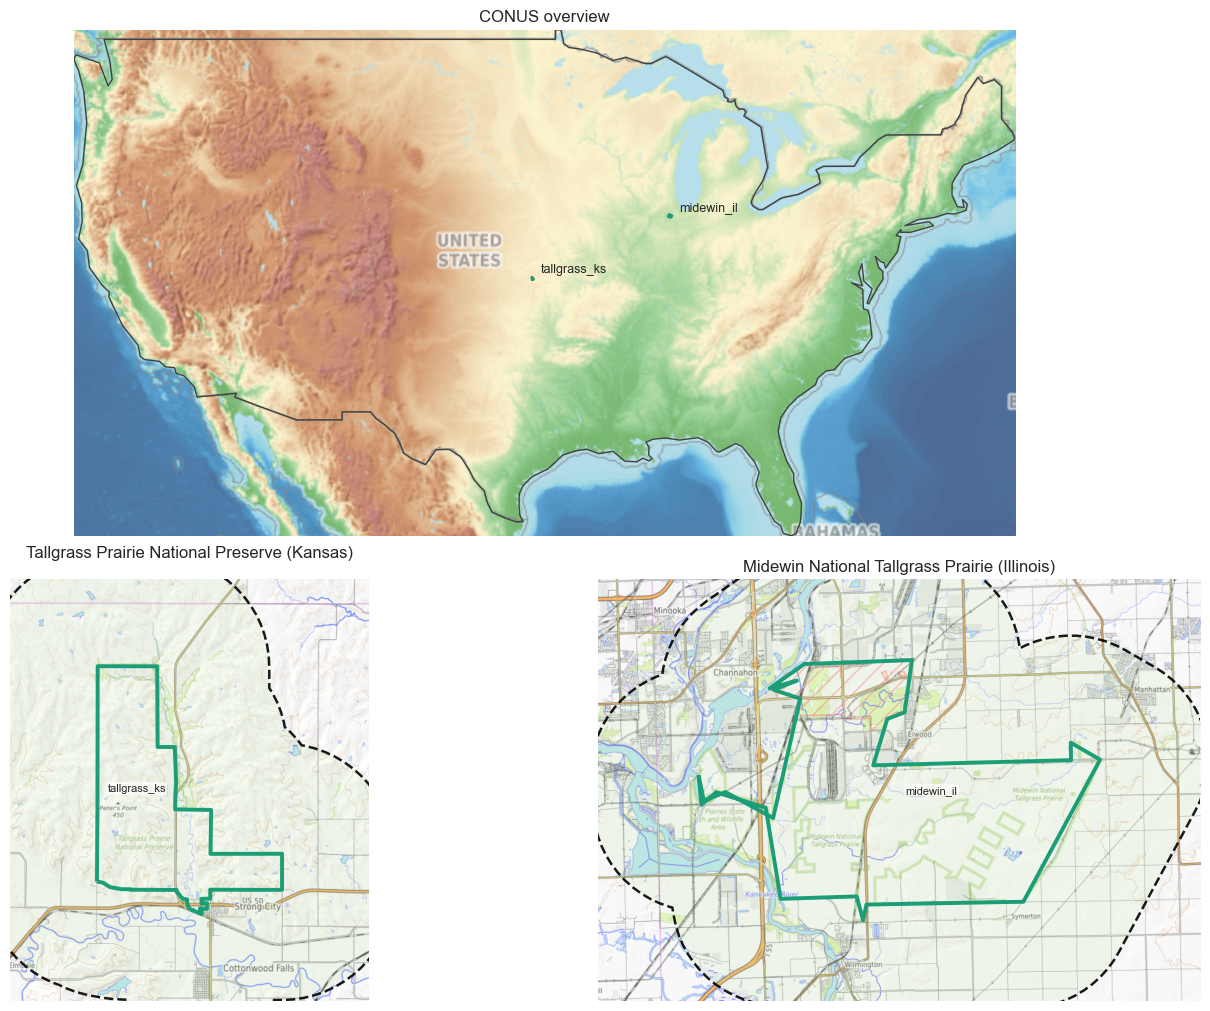

In [12]:
# +++Plotting: CONUS overview on top, site panels below+++ #

try:
    import contextily as ctx
    HAS_CTX = True
except ImportError:
    HAS_CTX = False

# --- Build a true CONUS outline ---
usa_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(usa_url)

usa = world.loc[world["ADMIN"] == "United States of America"].to_crs("EPSG:4326")

# Real geometric clip to CONUS bbox
conus_bbox = gpd.GeoDataFrame(
    geometry=[box(-125, 24, -66, 50)],
    crs="EPSG:4326",
)
conus_outline = gpd.clip(usa, conus_bbox)

# --- Reproject everything to Web Mercator for terrain basemap ---
conus_3857 = conus_outline.to_crs("EPSG:3857")
sites_3857 = sites_gdf.to_crs("EPSG:3857")

if "processing_sites_gdf" in globals():
    processing_sites_3857 = processing_sites_gdf.to_crs("EPSG:3857")
else:
    processing_sites_3857 = None

# Representative points for labels
overview_labels = sites_3857.copy()
overview_labels["label_pt"] = overview_labels.geometry.representative_point()

# --- Figure layout: top overview, bottom two site panels ---
fig = plt.figure(figsize=(14, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1])

ax_us = fig.add_subplot(gs[0, :])
ax_left = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1])

site_axes = {
    sites_gdf.iloc[0]["site_id"]: ax_left,
    sites_gdf.iloc[1]["site_id"]: ax_right,
}

# --- Top panel: CONUS overview ---
conus_3857.boundary.plot(ax=ax_us, color="0.25", linewidth=1.0)
sites_3857.boundary.plot(ax=ax_us, color="#1b9e77", linewidth=2.0)

for rec in overview_labels.itertuples():
    x, y = rec.label_pt.x, rec.label_pt.y
    ax_us.text(x + 60000, y + 40000, rec.site_id, fontsize=9)

if HAS_CTX:
    ctx.add_basemap(
        ax_us,
        source=ctx.providers.OpenTopoMap,
        alpha=0.7,
        attribution=False,
    )

minx, miny, maxx, maxy = conus_3857.total_bounds
ax_us.set_xlim(minx, maxx)
ax_us.set_ylim(miny, maxy)
ax_us.set_title("CONUS overview")
ax_us.set_axis_off()

# --- Bottom panels: each site ---
for rec in sites_gdf.itertuples():
    ax = site_axes[rec.site_id]

    site_poly_4326 = sites_gdf.loc[sites_gdf["site_id"] == rec.site_id]
    site_poly_3857 = site_poly_4326.to_crs("EPSG:3857")

    if processing_sites_3857 is not None:
        site_buffer_3857 = processing_sites_3857.loc[processing_sites_3857["site_id"] == rec.site_id]
    else:
        site_buffer_3857 = None

    minx, miny, maxx, maxy = site_poly_3857.total_bounds
    xpad = max(5000, (maxx - minx) * 0.25)
    ypad = max(5000, (maxy - miny) * 0.25)
    ax.set_xlim(minx - xpad, maxx + xpad)
    ax.set_ylim(miny - ypad, maxy + ypad)

    if HAS_CTX:
        ctx.add_basemap(
            ax,
            source=ctx.providers.OpenTopoMap,
            alpha=0.7,
            attribution=False,
        )

    # Buffered processing boundary: faint fill + bold dashed outline
    if site_buffer_3857 is not None and not site_buffer_3857.empty:
        site_buffer_3857.plot(
            ax=ax,
            facecolor="#b2df8a",
            edgecolor="none",
            alpha=0.12,
            zorder=2,
        )
        site_buffer_3857.boundary.plot(
            ax=ax,
            color="black",
            linewidth=1.8,
            linestyle="--",
            alpha=0.9,
            zorder=3,
        )

    # Official site boundary: solid green on top
    site_poly_3857.boundary.plot(
        ax=ax,
        color="#1b9e77",
        linewidth=2.8,
        zorder=4,
    )

    label_pt = site_poly_3857.geometry.representative_point().iloc[0]
    ax.text(
        label_pt.x,
        label_pt.y,
        rec.site_id,
        fontsize=8,
        ha="center",
        va="center",
        bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=1),
        zorder=5,
    )

    ax.set_title(f"{rec.site_name} ({rec.state})")
    ax.set_axis_off()

# --- Save figure ---
site_map_path = FIG_DIR / "site_maps.png"

fig.savefig(site_map_path, dpi=300, bbox_inches="tight")

print(f"Saved figure to: {site_map_path}")

plt.show()

In [13]:
#+++Print Summaries+++#
# Debugging checkpoint to make sure everything is correct so far

print(f"Species: {SPECIES_NAME}")
print(f"Site map saved to: {site_map_path}")
print(f"Climate models: {', '.join(climate_models)}")
print("Time periods:", [tp["period"] for tp in time_periods])

Species: Sorghastrum nutans (Indiangrass)
Site map saved to: c:\Users\kayle\Desktop\earth-analytics\spring-03-habitat-suitability-climate-change-kward-alt\figures\site_maps.png
Climate models: CanESM2, CNRM-CM5, HadGEM2-ES365, inmcm4
Time periods: ['historical_1981_2010', 'future_2041_2070']


## Site descriptions [**Reflect and Respond**]

I selected two prairie-focused sites in different parts of the species range:

**The Last "Stand" or the Tallgrass Prairie National Preserve, Kansas** 

The National Park Service notes that "tallgrass prairie once covered 170 million acres of North America...[but] today less than 4% remains intact, mostly in the Kansas Flint Hills." [National Park Service, n.d.; National Preserve Kansas]

As such the Flint Hills tallgrass landscape has a relatively intact prairie and strong fire-grazing ecological dynamics. This site makes for good comparison to Illinois where that has been mostly a restoration project not a conservation project. 

We can also see in the Kansas map that the surrounding area is also unfragmented and not interrupted by other land cover, namely built environments. 

**From Munitions to Grass? The Midewin National Tallgrass Prairie, Illinois** 

The Illinois site is a large restoration project. As noted by the U.S. Forestry Service (n.d.), the site "[Turns] back the clock from a landscape dominated by rusting munitions factories and abandoned ammunitions bunkers into a 20,283-acre pristine tallgrass prairie." They go one to embellish that this, "makes the Midewin a compelling vision for landscape scale restoration."

Of course, we know that this site is not *pristine* especially if it was previously a significantly disturbed site by a *different* form of *"fire."* 

Noteably, the Illinois site is very different from the Kansas site. The area around Midewin are very developed and there is a lot of fragmentation.

**Expected suitability**

I expect both sites to remain at least mostly suitable because _S. nutans_ is broadly distributed across the U.S., and based on its traits, seems to establish itself well as long as woody invasives are managed. Similarly, both sites are (seemingly) cared for due to the threatened status of indiangrass. However, I do expect **greater climate-model spread** in projected suitability at Midewin (IL) because it is a more fragmented site, and may be more sensitive to precipitation-seasonality shifts. Tallgrass (KS) should remain comparatively strong since this habitat has been preserved and not disturbed by ammunition.

**I think the main driver is not actually climate change for the Midewin site but what urban development is going on around it that may impact suitability. For example, pH changes, salinity, etc** Of course, there is no way to fuzzy map that, but it is a covariate that I can't account for. 

**References**
National Park Service. n.d. National Preserve Kansas. https://www.nps.gov/tapr/index.htm 
U.S. Forestry Service. n.d. Midewin National Tallgrass Prairie. https://www.fs.usda.gov/r09/midewin 

### Step 1c: Select time periods

For my climate normals, I used 1981-2010 and 2041-2070. I had to use a different link to acces the data as my download kept crashing my kernel. As a result my "historical" range is shifted forward by 5 years due to the data used but I don't expect this to drastically affect the modeling output. 

## Picking two time periods [**Reflect and Respond**]

- **Historical baseline: 1981-2010** (MACAv2 historical scenario)
- **Mid-century future: 2041-2070** (MACAv2 RCP8.5 scenario)

This pair should provide a good baseline and future modeling comparison. However, the two sites should likely be modeled with their own independent set of time periods (even though that doesn't allow for comparison then). I say this because the Tallgrass (KS) site was established in 1996 and has been preserved for 30 years now so the habitat is more stable. In comparison the Midewin (IL) site was "established" in 1996, but due to the reclamation process, was not actually finished until 2004. That is almost a decade of difference between the two sites in terms of establishment. 

### Step 1d: Select climate models [**Reflect and Respond**]

### Climate models used
This analysis uses four global climate models (GCMs). These models simulate future climate under the RCP8.5 emissions scenario and are commonly used to capture uncertainty across different climate projections.

Models Used:

1. CanESM2 (Canada) [best fit for warm & wet]

- Developed by: Canadian Centre for Climate Modelling and Analysis
- Type: Earth system model (includes carbon cycle feedbacks)
- General traits:
    - Often shows warmer and wetter futures
    - Can "produce" strong vegetation and ecosystem responses
    - Why included:
        - Represents a higher-sensitivity climate response
        - Because I am using precipitation and soil ph this model may provide a good assessment for Indiangrass (can handle dry and wet years)

2. CNRM-CM5 (France) [best fit for more "moderate" conditions]

- Developed by: Centre National de Recherches Météorologiques
- Type: Coupled atmosphere–ocean model
- General traits:
    - Typically produces moderate warming signals
    - Often considered middle-of-the-road among CMIP5 models
    - Why included:
        - Serves as a baseline / moderate scenario
        - Since Indiangrass is established across much of the U.S. a more "intermediate" scenario could suit it better since it seems to thrive pretty much anywhere that it gets established (and not crowded out by woody species)

3. HadGEM2-ES (United Kingdom) [best fit for warm & dry]

- Developed by: Met Office Hadley Centre
- Type: Earth system model (includes atmospheric chemistry + carbon cycle)
- General traits:
    - Often projects strong warming and drying in some regions
    - Captures complex land–atmosphere interactions
        - Why included:
            - Represents perhaps the most *reasonable* model for the two sites in the future, as both Kansas and Illinois are getting warmer but not wetter (CanESM2)

4. inmcm4 (Russia) [best for counterfactual cooler & dry]

- Developed by: Institute of Numerical Mathematics
- Type: Coupled climate model
- General traits:
    - Often shows lower climate sensitivity
    - Produces more conservative (muted) changes
    - Why included:
        - Provides a more conservative projection
        - Thought it would provide an interesting contrast to the other models since Indiangrass does not have a high cold tolerance

Climate Toolbox reference: Climate Toolbox model-selection resources and MACA model comparison tools ([https://climatetoolbox.org](https://climatetoolbox.org/tool/Future-Climate-Scatter)).


## STEP 2: Data access

### Step 2a: Soil data

I pulled the soil data from the [POLARIS dataset](http://hydrology.cee.duke.edu/POLARIS/) based on the PLANTS database criteria I specified earlier in the indiangrass introduction. Since the minimum depth of roots for indiangrass is 24 inches, I am using the 60 to 100 cm depth in POLARIS. 24 inches is approximately 60 cm and since it is the minimum, the 60cm to 100cm depth is most suitable. 

In [14]:
#+++Creating function, downloading data, creating dataframes+++#
def _polaris_tile_ids(boundary_gdf):
    """Create POLARIS 1x1 degree tile identifiers for a boundary."""
    minx, miny, maxx, maxy = boundary_gdf.to_crs("EPSG:4326").total_bounds
    lon_vals = range(int(np.floor(minx)), int(np.ceil(maxx)))
    lat_vals = range(int(np.floor(miny)), int(np.ceil(maxy)))
    return [(lat, lon) for lat in lat_vals for lon in lon_vals]


def download_polaris_for_boundary(
    boundary_gdf,
    variable="ph",
    depth="60_100",
    statistic="mean",
    raw_dir=RAW_DIR / "soil",
    out_path=None,
):
    """Download, mosaic, and crop POLARIS tiles for a study boundary."""
    boundary_4326 = boundary_gdf.to_crs("EPSG:4326")
    raw_dir = Path(raw_dir)
    tile_dir = raw_dir / variable / statistic / depth
    tile_dir.mkdir(parents=True, exist_ok=True)

    base_url = "http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0"
    tile_paths = []

    for lat, lon in _polaris_tile_ids(boundary_4326):
        tile_name = f"lat{lat}{lat+1}_lon{lon}{lon+1}.tif"
        tile_path = tile_dir / tile_name

        if not tile_path.exists():
            url = f"{base_url}/{variable}/{statistic}/{depth}/{tile_name}"
            try:
                resp = requests.get(url, timeout=120)
                if resp.status_code == 200:
                    tile_path.write_bytes(resp.content)
                    print(f"  downloaded POLARIS tile: {tile_name}")
                else:
                    print(f"  missing POLARIS tile (HTTP {resp.status_code}): {tile_name}")
            except requests.RequestException as exc:
                print(f"  request failed for {tile_name}: {exc}")
        else:
            print(f"  using cached POLARIS tile: {tile_name}")

        if tile_path.exists():
            tile_paths.append(tile_path)

    if not tile_paths:
        raise RuntimeError("No POLARIS tiles were downloaded for this boundary.")

    arrays = [rxr.open_rasterio(path, masked=True).squeeze(drop=True) for path in tile_paths]
    soil_mosaic = merge_arrays(arrays)
    if soil_mosaic.rio.crs is None:
        soil_mosaic = soil_mosaic.rio.write_crs("EPSG:4326")

    boundary_for_clip = boundary_4326.to_crs(soil_mosaic.rio.crs)
    soil_clipped = soil_mosaic.rio.clip(boundary_for_clip.geometry, boundary_for_clip.crs, drop=True)

    if out_path is None:
        out_path = PROC_DIR / "soil" / f"soil_{variable}_{depth}.tif"
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    soil_clipped.rio.to_raster(out_path, compress="lzw")
    return out_path


#+++Create soil dataframe+++#
soil_records = []
for rec in sites_gdf.itertuples():
    print(f"Processing soil data for {rec.site_id}...")
    site_boundary = sites_gdf.loc[sites_gdf["site_id"] == rec.site_id].copy()
    out_path = PROC_DIR / "soil" / f"{rec.site_id}_{SOIL_VARIABLE}_{SOIL_DEPTH}.tif"

    try:
        soil_path = download_polaris_for_boundary(
            boundary_gdf=site_boundary,
            variable=SOIL_VARIABLE,
            depth=SOIL_DEPTH,
            statistic="mean",
            raw_dir=RAW_DIR / "soil",
            out_path=out_path,
        )
        soil_records.append(
            {
                "site_id": rec.site_id,
                "site_name": rec.site_name,
                "soil_path": str(soil_path),
                "boundary_source": getattr(rec, "boundary_source", "official_boundary"),
                "clip_boundary": "official_boundary",
            }
        )
    except Exception as exc:
        print(f"  soil processing failed for {rec.site_id}: {exc}")

soil_manifest_df = pd.DataFrame(soil_records)
soil_manifest_df


Processing soil data for tallgrass_ks...
  using cached POLARIS tile: lat3839_lon-97-96.tif
Processing soil data for midewin_il...
  using cached POLARIS tile: lat4142_lon-89-88.tif


,site_id,site_name,soil_path,boundary_source,clip_boundary
0,tallgrass_ks,Tallgrass Prairie National Preserve,c:\Users\kayle\Desktop\earth-analytics\spring-...,NPS Tallgrass Prairie National Preserve Tract ...,official_boundary
1,midewin_il,Midewin National Tallgrass Prairie,c:\Users\kayle\Desktop\earth-analytics\spring-...,USFS Forest Administrative Boundaries map serv...,official_boundary


### Debug note

So the POLARIS naming convention used by the XPolaris downloader builds filenames with lat and lon prefixes, like: lat3839_lon-97-96.tif 

I previously used tile_name = f"{lat}{lat+1}_{lon}{lon+1}.tif" but we need to use this to accomodate the prefixes or the data won't download (i.e., can't find .tif files):

tile_name = f"lat{lat}{lat+1}_lon{lon}{lon+1}.tif"

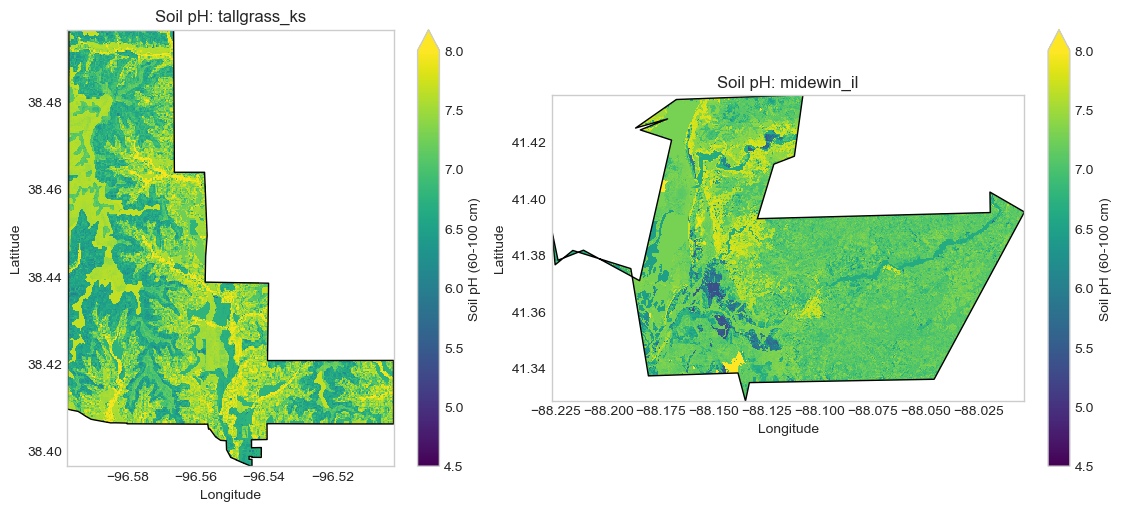

Saved soil figure: c:\Users\kayle\Desktop\earth-analytics\spring-03-habitat-suitability-climate-change-kward-alt\figures\soil_ph_maps.png


In [19]:
# Visualize processed soil pH rasters
if soil_manifest_df.empty:
    raise RuntimeError("No processed soil rasters found. Run the previous soil cell first.")

n_sites = len(soil_manifest_df)
fig, axes = plt.subplots(1, n_sites, figsize=(6 * n_sites, 5), constrained_layout=True)

if n_sites == 1:
    axes = [axes]

for ax, rec in zip(axes, soil_manifest_df.itertuples()):
    soil_da = rxr.open_rasterio(rec.soil_path, masked=True).squeeze(drop=True)

    site_boundary = official_sites_gdf.loc[
        official_sites_gdf["site_id"] == rec.site_id
    ].copy()

    site_boundary_raster = site_boundary.to_crs(soil_da.rio.crs)

    soil_plot_da = soil_da.rio.clip(
        site_boundary_raster.geometry,
        site_boundary_raster.crs,
        drop=True
    )

    soil_plot_da.plot(
        ax=ax,
        cmap="viridis",
        vmin=4.5,
        vmax=8.0,
        cbar_kwargs={"label": "Soil pH (60-100 cm)"},
    )

    site_boundary_raster.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1.0
    )

    ax.set_title(f"Soil pH: {rec.site_id}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

soil_fig_path = FIG_DIR / "soil_ph_maps.png"
fig.savefig(soil_fig_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved soil figure: {soil_fig_path}")

## Soil pH maps

The deep dark blue areas on these maps are water, which I also confirmed via google earth. I expect there is a lot of fertilizer run off in these areas as there is both agriculture and built environments near these sites. We can see across these maps that beyond water sources, the rest of the landscape meets the pH range for Indiangrass as we expected (4.8-8.0). 

## Boundary note, Boundarygate cont.
I now clip analyses to official administrative/preserve boundaries (USFS for Midewin and NPS tract/boundary data for Tallgrass). A buffered version may be used during raster processing to reduce edge artifacts, but final map outputs are clipped back to the true site boundaries.


### Step 2b: Topographic data

Here I plot out the elevation of the two sites. As one would expect from Kansas and Illinois they do not have very heterogenious elevations (e.g. mountains). 

In [20]:
_EARTHACCESS_SESSION = None


def authenticate_earthaccess():
    """Authenticate with NASA Earthdata through earthaccess."""
    global _EARTHACCESS_SESSION
    if _EARTHACCESS_SESSION is None:
        print("Authenticating with NASA Earthdata via earthaccess...")
        _EARTHACCESS_SESSION = earthaccess.login(persist=True)
    return _EARTHACCESS_SESSION


def _calculate_slope_degrees(dem_da):
    """Calculate slope (degrees) from a projected elevation raster."""
    transform = dem_da.rio.transform()
    x_res = abs(transform.a)
    y_res = abs(transform.e)

    z = dem_da.values.astype("float64")
    dz_dy, dz_dx = np.gradient(z, y_res, x_res)
    slope = np.degrees(np.arctan(np.sqrt(dz_dx ** 2 + dz_dy ** 2)))
    slope = np.where(np.isfinite(z), slope, np.nan)

    slope_da = xr.DataArray(
        slope,
        coords=dem_da.coords,
        dims=dem_da.dims,
        name="slope_deg",
        attrs={"long_name": "Slope", "units": "degrees"},
    )
    slope_da = slope_da.rio.write_crs(dem_da.rio.crs)
    return slope_da


def download_srtm_and_derive_topography(
    boundary_gdf,
    site_id,
    raw_dir=RAW_DIR / "topography",
    proc_dir=PROC_DIR / "topography",
    target_crs="EPSG:5070",
):
    """Download SRTM elevation and derive topographic variables."""
    authenticate_earthaccess()
    boundary_4326 = boundary_gdf.to_crs("EPSG:4326")
    minx, miny, maxx, maxy = boundary_4326.total_bounds

    site_raw_dir = Path(raw_dir) / site_id
    site_raw_dir.mkdir(parents=True, exist_ok=True)

    raster_exts = {".hgt", ".tif", ".img", ".dem"}
    existing_rasters = [p for p in site_raw_dir.rglob("*") if p.suffix.lower() in raster_exts]

    if not existing_rasters:
        granules = earthaccess.search_data(
            short_name="SRTMGL1",
            bounding_box=(minx, miny, maxx, maxy),
            count=200,
        )
        if not granules:
            granules = earthaccess.search_data(
                short_name="SRTMGL1_NC",
                bounding_box=(minx, miny, maxx, maxy),
                count=200,
            )
        if not granules:
            raise RuntimeError(f"No SRTM granules found for {site_id}.")

        print(f"  downloading {len(granules)} SRTM granules for {site_id}...")
        earthaccess.download(granules, local_path=str(site_raw_dir))

    for zip_path in site_raw_dir.rglob("*.zip"):
        try:
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(zip_path.parent)
        except zipfile.BadZipFile:
            print(f"  warning: could not extract {zip_path.name}")

    raster_paths = [p for p in site_raw_dir.rglob("*") if p.suffix.lower() in raster_exts]
    if not raster_paths:
        raise RuntimeError(f"No readable SRTM rasters found for {site_id} after download.")

    dem_arrays = [rxr.open_rasterio(path, masked=True).squeeze(drop=True) for path in raster_paths]
    dem_mosaic = merge_arrays(dem_arrays)
    boundary_for_clip = boundary_4326.to_crs(dem_mosaic.rio.crs)
    dem_clipped = dem_mosaic.rio.clip(boundary_for_clip.geometry, boundary_for_clip.crs, drop=True)

    dem_projected = dem_clipped.rio.reproject(target_crs, resolution=30)
    slope_projected = _calculate_slope_degrees(dem_projected)

    dem_out = Path(proc_dir) / f"{site_id}_dem_{target_crs.replace(':', '')}.tif"
    slope_out = Path(proc_dir) / f"{site_id}_slope_{target_crs.replace(':', '')}.tif"
    dem_out.parent.mkdir(parents=True, exist_ok=True)

    dem_projected.rio.to_raster(dem_out, compress="lzw")
    slope_projected.rio.to_raster(slope_out, compress="lzw")

    return {"dem_path": str(dem_out), "slope_path": str(slope_out)}


topo_records = []
for rec in sites_gdf.itertuples():
    print(f"Processing topography for {rec.site_id}...")
    site_boundary = sites_gdf.loc[sites_gdf["site_id"] == rec.site_id].copy()
    try:
        topo_paths = download_srtm_and_derive_topography(site_boundary, site_id=rec.site_id)
        topo_records.append(
            {
                "site_id": rec.site_id,
                "site_name": rec.site_name,
                "dem_path": topo_paths["dem_path"],
                "slope_path": topo_paths["slope_path"],
                "boundary_source": getattr(rec, "boundary_source", "official_boundary"),
                "clip_boundary": "official_boundary",
            }
        )
    except Exception as exc:
        print(f"  topography processing failed for {rec.site_id}: {exc}")

topo_manifest_df = pd.DataFrame(topo_records)
topo_manifest_df


Processing topography for tallgrass_ks...
Authenticating with NASA Earthdata via earthaccess...
Processing topography for midewin_il...


,site_id,site_name,dem_path,slope_path,boundary_source,clip_boundary
0,tallgrass_ks,Tallgrass Prairie National Preserve,c:\Users\kayle\Desktop\earth-analytics\spring-...,c:\Users\kayle\Desktop\earth-analytics\spring-...,NPS Tallgrass Prairie National Preserve Tract ...,official_boundary
1,midewin_il,Midewin National Tallgrass Prairie,c:\Users\kayle\Desktop\earth-analytics\spring-...,c:\Users\kayle\Desktop\earth-analytics\spring-...,USFS Forest Administrative Boundaries map serv...,official_boundary


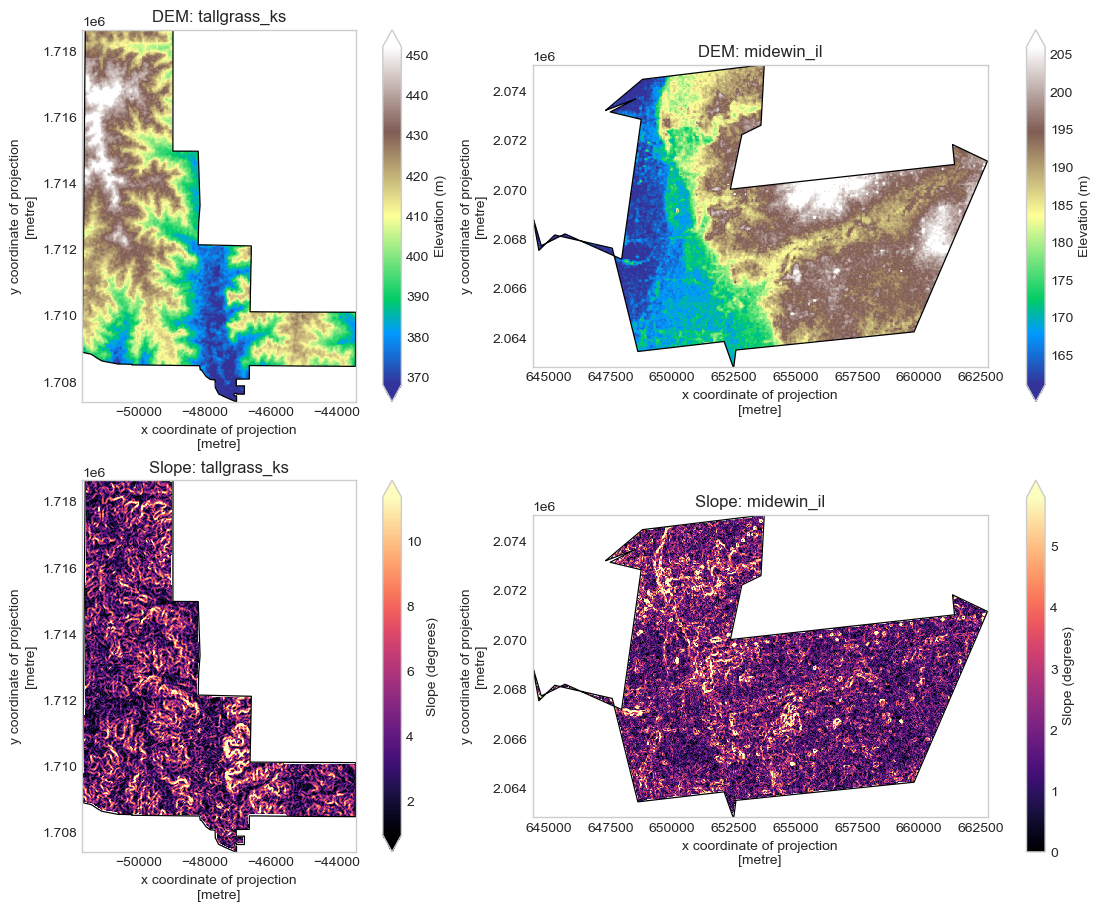

Saved topography figure: c:\Users\kayle\Desktop\earth-analytics\spring-03-habitat-suitability-climate-change-kward-alt\figures\topography_maps.png


In [21]:
# Visualize elevation and slope rasters
if topo_manifest_df.empty:
    raise RuntimeError("No processed topographic rasters found. Run the previous topography cell first.")

n_sites = len(topo_manifest_df)
fig, axes = plt.subplots(2, n_sites, figsize=(6 * n_sites, 9), constrained_layout=True)
if n_sites == 1:
    axes = np.array(axes).reshape(2, 1)

for col, rec in enumerate(topo_manifest_df.itertuples()):
    dem_da = rxr.open_rasterio(rec.dem_path, masked=True).squeeze(drop=True)
    slope_da = rxr.open_rasterio(rec.slope_path, masked=True).squeeze(drop=True)

    site_boundary = official_sites_gdf.loc[official_sites_gdf["site_id"] == rec.site_id].copy()
    dem_boundary = site_boundary.to_crs(dem_da.rio.crs)
    slope_boundary = site_boundary.to_crs(slope_da.rio.crs)

    dem_plot_da = dem_da.rio.clip(dem_boundary.geometry, dem_boundary.crs, drop=True)
    slope_plot_da = slope_da.rio.clip(slope_boundary.geometry, slope_boundary.crs, drop=True)

    dem_plot_da.plot(
        ax=axes[0, col],
        cmap="terrain",
        robust=True,
        cbar_kwargs={"label": "Elevation (m)"},
    )
    dem_boundary.boundary.plot(ax=axes[0, col], color="black", linewidth=0.9)
    axes[0, col].set_title(f"DEM: {rec.site_id}")
    axes[0, col].set_aspect("equal")

    slope_plot_da.plot(
        ax=axes[1, col],
        cmap="magma",
        robust=True,
        cbar_kwargs={"label": "Slope (degrees)"},
    )
    slope_boundary.boundary.plot(ax=axes[1, col], color="black", linewidth=0.9)
    axes[1, col].set_title(f"Slope: {rec.site_id}")
    axes[1, col].set_aspect("equal")

topo_fig_path = FIG_DIR / "topography_maps.png"
fig.savefig(topo_fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved topography figure: {topo_fig_path}")


### Step 2c: Climate model data

## Debugging note

I do not have dask in this environment so I installed it in terminal. If you also do not have it run the following in terminal: 

- conda activate [your environment]
- conda install -c conda-forge dask

Dask is helpful for data scaling with limited memory. The documentation states: Dask processes datasets larger than memory (out-of-memory) by operating on chunks, allowing dask.dataframe to handle massive tabular data and dask.array to handle large-scale numerical data.

After the 3rd iteration of this cell, I got a DAP error so there is a timeout happening. So now I will open URLs one at a time and subsetting immediately. I had to import time for this.

In [22]:
# +++ Climate helper functions +++ #

import time

def _get_ds_var_name(ds, variable):
    """Map MACA filename variable codes to NetCDF data variable names."""
    preferred = {
        "pr": ["precipitation_amount", "precipitation", "pr"],
        "tasmin": ["air_temperature", "tasmin"],
        "tasmax": ["air_temperature", "tasmax"],
        "uas": ["eastward_wind", "uas"],
        "vas": ["northward_wind", "vas"],
        "rsds": ["surface_downwelling_shortwave_flux_in_air", "rsds"],
        "huss": ["specific_humidity", "huss"],
        "rhsmax": ["relative_humidity", "rhsmax"],
        "rhsmin": ["relative_humidity", "rhsmin"],
    }

    candidates = preferred.get(variable, [variable])

    for name in candidates:
        if name in ds.data_vars:
            return name

    data_vars = list(ds.data_vars)
    if len(data_vars) == 1:
        return data_vars[0]

    raise KeyError(
        f"Variable '{variable}' not found. Available data vars: {data_vars}"
    )


def _get_maca_opendap_urls(variable, model, scenario, start_year, end_year):
    """Find MACAv2 daily OPeNDAP files intersecting the target years for one model/scenario."""
    catalog_url = f"https://www.reacchpna.org/thredds/catalog/MACAV2/{model}/catalog.xml"
    resp = requests.get(catalog_url, timeout=120)
    resp.raise_for_status()

    root = ET.fromstring(resp.text)
    datasets = root.findall(".//{*}dataset")

    pattern = re.compile(
        rf"macav2metdata_{re.escape(variable)}_{re.escape(model)}_"
        rf"(?P<run>r\d+i\d+p\d+)_{scenario}_(?P<start>\d{{4}})_(?P<end>\d{{4}})_CONUS_daily\.nc$"
    )

    matches = []
    for ds_meta in datasets:
        name = ds_meta.attrib.get("name", "")
        url_path = ds_meta.attrib.get("urlPath", "")
        m = pattern.search(name)
        if not m:
            continue

        seg_start = int(m.group("start"))
        seg_end = int(m.group("end"))
        overlaps = not (seg_end < start_year or seg_start > end_year)

        if overlaps and url_path:
            matches.append(
                (seg_start, f"https://www.reacchpna.org/thredds/dodsC/{url_path}")
            )

    if not matches:
        raise RuntimeError(
            f"No MACAv2 files found for var={variable}, model={model}, "
            f"scenario={scenario}, years={start_year}-{end_year}."
        )

    matches.sort(key=lambda x: x[0])
    return [url for _, url in matches]


def _open_maca_subset_with_retry(
    url,
    variable,
    minx,
    miny,
    maxx,
    maxy,
    start_year,
    end_year,
    max_attempts=3,
    wait_seconds=4,
):
    """Open one MACA OPeNDAP URL, subset immediately, and retry on transient failures."""
    last_exc = None

    for attempt in range(1, max_attempts + 1):
        ds = None
        try:
            # Use a single remote file at a time to reduce DAP failures
            ds = xr.open_dataset(url, engine="netcdf4")

            ds_var = _get_ds_var_name(ds, variable)
            data = ds[ds_var]

            # Normalize longitude if needed
            if "lon" in data.coords and float(data.lon.max()) > 180:
                data = data.assign_coords(
                    lon=(((data.lon + 180) % 360) - 180)
                ).sortby("lon")

            lat_desc = bool(data.lat.values[0] > data.lat.values[-1])
            lat_slice = slice(maxy, miny) if lat_desc else slice(miny, maxy)

            subset = data.sel(
                lon=slice(minx, maxx),
                lat=lat_slice,
                time=slice(f"{start_year}-01-01", f"{end_year}-12-31"),
            )

            # Force the small subset into memory now, while the file is open
            subset = subset.load()

            if subset.sizes.get("time", 0) == 0:
                raise RuntimeError(f"No time data returned from {url}")

            return subset

        except Exception as exc:
            last_exc = exc
            print(f"    attempt {attempt}/{max_attempts} failed for remote subset: {exc}")
            time.sleep(wait_seconds)

        finally:
            if ds is not None:
                try:
                    ds.close()
                except Exception:
                    pass

    raise RuntimeError(f"Failed to read remote subset after {max_attempts} attempts: {last_exc}")


def download_maca_climate_normal(
    boundary_gdf,
    variable,
    model,
    scenario,
    start_year,
    end_year,
    out_path,
):
    """Build a 30-year MACAv2 climate normal raster for a site."""
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    if out_path.exists():
        print(f"  using cached climate raster: {out_path.name}")
        return out_path

    boundary_4326 = boundary_gdf.to_crs("EPSG:4326")

    minx, miny, maxx, maxy = boundary_4326.total_bounds
    buffer_deg = 0.10
    minx -= buffer_deg
    miny -= buffer_deg
    maxx += buffer_deg
    maxy += buffer_deg

    urls = _get_maca_opendap_urls(variable, model, scenario, start_year, end_year)
    print(f"  opening {len(urls)} MACA OPeNDAP files for {model} ({scenario})...")

    subsets = []
    for i, url in enumerate(urls, start=1):
        print(f"    reading remote file {i}/{len(urls)}")
        sub = _open_maca_subset_with_retry(
            url=url,
            variable=variable,
            minx=minx,
            miny=miny,
            maxx=maxx,
            maxy=maxy,
            start_year=start_year,
            end_year=end_year,
            max_attempts=3,
            wait_seconds=4,
        )
        subsets.append(sub)

    if not subsets:
        raise RuntimeError("No MACA subsets were successfully read.")

    # Combine locally after the remote pieces are already subset + loaded
    data = xr.concat(subsets, dim="time").sortby("time")

    print("  combined dims:", data.dims)
    print(
        f"  subset shape: time={data.sizes.get('time', 0)}, "
        f"lat={data.sizes.get('lat', 0)}, lon={data.sizes.get('lon', 0)}"
    )

    if data.sizes.get("lat", 0) < 2 or data.sizes.get("lon", 0) < 2:
        raise RuntimeError(
            f"Subset too small after bounding-box selection: "
            f"lat={data.sizes.get('lat', 0)}, lon={data.sizes.get('lon', 0)}"
        )

    if variable == "pr":
        annual = data.resample(time="YS").sum(skipna=True)
        clim = annual.mean("time", skipna=True)
        clim.attrs["units"] = "mm/year"
    else:
        annual = data.resample(time="YS").mean(skipna=True)
        clim = annual.mean("time", skipna=True)
        if float(clim.quantile(0.5)) > 100:
            clim = clim - 273.15
            clim.attrs["units"] = "degC"

    print("  clim dims:", clim.dims)
    print("  clim shape:", clim.shape)

    clim = clim.sortby("lat")
    clim = clim.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    clim = clim.rio.write_crs("EPSG:4326", inplace=False)
    clim = clim.rio.write_coordinate_system(inplace=False)
    clim = clim.rio.write_transform(inplace=False)
    clim = clim.astype("float32").load()

    clim.rio.to_raster(out_path, compress="lzw")
    return out_path

# +++ Run climate processing +++ #

climate_records = []
expected_count = len(official_sites_gdf) * len(time_periods) * len(climate_models)
print(f"Target climate rasters (minimum for assignment): {expected_count}")

for site_rec in official_sites_gdf.itertuples():
    site_boundary = official_sites_gdf.loc[official_sites_gdf["site_id"] == site_rec.site_id].copy()

    for period in time_periods:
        for model in climate_models:
            out_path = (
                PROC_DIR
                / "climate"
                / site_rec.site_id
                / model
                / f"{site_rec.site_id}_{model}_{period['period']}_{CLIMATE_VARIABLE}.tif"
            )

            print(
                f"Processing climate for site={site_rec.site_id}, "
                f"model={model}, period={period['period']}..."
            )

            try:
                climate_path = download_maca_climate_normal(
                    boundary_gdf=site_boundary,
                    variable=CLIMATE_VARIABLE,
                    model=model,
                    scenario=period["scenario"],
                    start_year=period["start_year"],
                    end_year=period["end_year"],
                    out_path=out_path,
                )

                climate_records.append(
                    {
                        "site_id": site_rec.site_id,
                        "site_name": site_rec.site_name,
                        "model": model,
                        "period": period["period"],
                        "scenario": period["scenario"],
                        "start_year": period["start_year"],
                        "end_year": period["end_year"],
                        "variable": CLIMATE_VARIABLE,
                        "climate_path": str(climate_path),
                        "boundary_source": site_rec.boundary_source,
                        "clip_boundary": "official_boundary_bbox",
                    }
                )

            except Exception as exc:
                print(
                    f"  climate processing failed for {site_rec.site_id} | "
                    f"{model} | {period['period']}: {exc}"
                )

climate_manifest_df = pd.DataFrame(climate_records)
print(f"Successfully created {len(climate_manifest_df)} climate rasters.")

if len(climate_manifest_df) < expected_count:
    print("Warning: fewer climate rasters were created than requested. Check log messages above.")

climate_manifest_df.head()


Target climate rasters (minimum for assignment): 16
Processing climate for site=tallgrass_ks, model=CanESM2, period=historical_1981_2010...
  opening 6 MACA OPeNDAP files for CanESM2 (historical)...
    reading remote file 1/6
    reading remote file 2/6
    reading remote file 3/6
    reading remote file 4/6
    reading remote file 5/6
    reading remote file 6/6
  combined dims: ('time', 'lat', 'lon')
  subset shape: time=9131, lat=7, lon=7
  clim dims: ('lat', 'lon')
  clim shape: (7, 7)
Processing climate for site=tallgrass_ks, model=CNRM-CM5, period=historical_1981_2010...
  opening 6 MACA OPeNDAP files for CNRM-CM5 (historical)...
    reading remote file 1/6
    reading remote file 2/6
    reading remote file 3/6
    reading remote file 4/6
    reading remote file 5/6
    reading remote file 6/6
  combined dims: ('time', 'lat', 'lon')
  subset shape: time=9131, lat=7, lon=7
  clim dims: ('lat', 'lon')
  clim shape: (7, 7)
Processing climate for site=tallgrass_ks, model=HadGEM2-ES

,site_id,site_name,model,period,scenario,start_year,end_year,variable,climate_path,boundary_source,clip_boundary
0,tallgrass_ks,Tallgrass Prairie National Preserve,CanESM2,historical_1981_2010,historical,1981,2010,pr,c:\Users\kayle\Desktop\earth-analytics\spring-...,NPS Tallgrass Prairie National Preserve Tract ...,official_boundary_bbox
1,tallgrass_ks,Tallgrass Prairie National Preserve,CNRM-CM5,historical_1981_2010,historical,1981,2010,pr,c:\Users\kayle\Desktop\earth-analytics\spring-...,NPS Tallgrass Prairie National Preserve Tract ...,official_boundary_bbox
2,tallgrass_ks,Tallgrass Prairie National Preserve,HadGEM2-ES365,historical_1981_2010,historical,1981,2010,pr,c:\Users\kayle\Desktop\earth-analytics\spring-...,NPS Tallgrass Prairie National Preserve Tract ...,official_boundary_bbox
3,tallgrass_ks,Tallgrass Prairie National Preserve,inmcm4,historical_1981_2010,historical,1981,2010,pr,c:\Users\kayle\Desktop\earth-analytics\spring-...,NPS Tallgrass Prairie National Preserve Tract ...,official_boundary_bbox
4,tallgrass_ks,Tallgrass Prairie National Preserve,CanESM2,future_2041_2070,rcp85,2041,2070,pr,c:\Users\kayle\Desktop\earth-analytics\spring-...,NPS Tallgrass Prairie National Preserve Tract ...,official_boundary_bbox


In [23]:
# Repair CRS metadata on written climate rasters because some outputs
# retained transform/bounds but did not persist the EPSG tag in the GeoTIFF.
import rasterio
from pathlib import Path

def repair_climate_crs(climate_manifest_df, epsg=4326):
    repaired = []

    for path_str in climate_manifest_df["climate_path"]:
        path = Path(path_str)

        with rasterio.open(path, "r+") as dst:
            dst.crs = rasterio.crs.CRS.from_epsg(epsg)

        repaired.append(str(path))
        print(f"Repaired CRS: {path.name}")

    return repaired

repaired_files = repair_climate_crs(climate_manifest_df, epsg=4326)
print(f"Repaired {len(repaired_files)} climate rasters.")

Repaired CRS: tallgrass_ks_CanESM2_historical_1981_2010_pr.tif
Repaired CRS: tallgrass_ks_CNRM-CM5_historical_1981_2010_pr.tif
Repaired CRS: tallgrass_ks_HadGEM2-ES365_historical_1981_2010_pr.tif
Repaired CRS: tallgrass_ks_inmcm4_historical_1981_2010_pr.tif
Repaired CRS: tallgrass_ks_CanESM2_future_2041_2070_pr.tif
Repaired CRS: tallgrass_ks_CNRM-CM5_future_2041_2070_pr.tif
Repaired CRS: tallgrass_ks_HadGEM2-ES365_future_2041_2070_pr.tif
Repaired CRS: tallgrass_ks_inmcm4_future_2041_2070_pr.tif
Repaired CRS: midewin_il_CanESM2_historical_1981_2010_pr.tif
Repaired CRS: midewin_il_CNRM-CM5_historical_1981_2010_pr.tif
Repaired CRS: midewin_il_HadGEM2-ES365_historical_1981_2010_pr.tif
Repaired CRS: midewin_il_inmcm4_historical_1981_2010_pr.tif
Repaired CRS: midewin_il_CanESM2_future_2041_2070_pr.tif
Repaired CRS: midewin_il_CNRM-CM5_future_2041_2070_pr.tif
Repaired CRS: midewin_il_HadGEM2-ES365_future_2041_2070_pr.tif
Repaired CRS: midewin_il_inmcm4_future_2041_2070_pr.tif
Repaired 16 clim

In [24]:
#Was having CRS issues in harmonization so added that to a repair function instead
#Testing here that the CRS appended to the metadata correctly so harmonization works
test_path = climate_manifest_df.loc[0, "climate_path"]
test_da = rxr.open_rasterio(test_path, masked=True).squeeze(drop=True)

print("CRS:", test_da.rio.crs)
print("Transform:", test_da.rio.transform())
print("Bounds:", test_da.rio.bounds())

CRS: EPSG:4326
Transform: | 0.04, 0.00,-96.71|
| 0.00, 0.04, 38.29|
| 0.00, 0.00, 1.00|
Bounds: (-96.71010335286458, 38.292033195495605, -96.41843668619792, 38.58369541168213)


In [25]:
#+++saving work+++#
#I had a lot of debugging in this function so I am saving this now

climate_manifest_df.to_csv(PROC_DIR / "climate" / "climate_manifest.csv", index=False)

## **Reflect and respond**

I used MACAv2-METDATA daily downscaled climate projections to characterize precipitation (pr) and computed 30-year climate normals by averaging annual precipitation totals over each target period. MACAv2 provides statistically downscaled climate data at ~4 km resolution, derived from CMIP5 global climate models and bias-corrected using historical observations.

Dataset setup:

- Historical baseline: 1981–2010 (historical)
- Future projection: 2041–2070 (rcp85)
- Variable: precipitation (pr) aggregated to annual totals and averaged to create climate normals

I selected four CMIP5 models (CanESM2, CNRM-CM5, HadGEM2-ES365, inmcm4) to capture a range of projected hydroclimate conditions. These models represent different precipitation sensitivities and regional responses, allowing for a more robust assessment of uncertainty in future climate conditions. Model selection was informed by the MACAv2 archive and Climate Toolbox resources.

Reference: 
MACAv2 data access: https://www.climatologylab.org/maca.html

## STEP 3: Harmonize data

In [26]:
def harmonize_layer_stack(
    boundary_gdf,
    layer_paths,
    out_dir,
    target_crs="EPSG:5070",
    buffer_m=5000,
    processing_boundary_5070=None,
):
    """Crop, reproject, and align raster layers to a common template."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    site_target = boundary_gdf.to_crs(target_crs)

    if processing_boundary_5070 is not None:
        processing_target = processing_boundary_5070.to_crs(target_crs).copy()
        effective_buffer_m = buffer_m
    elif buffer_m and buffer_m > 0:
        processing_target = site_target.copy()
        processing_target["geometry"] = processing_target.geometry.buffer(buffer_m)
        effective_buffer_m = buffer_m
    else:
        processing_target = site_target.copy()
        effective_buffer_m = 0

    projected_layers = {}
    for layer_name, layer_path in layer_paths.items():
        da = rxr.open_rasterio(layer_path, masked=True).squeeze(drop=True)
        if da.rio.crs is None:
            raise ValueError(f"Layer '{layer_name}' has no CRS: {layer_path}")

        processing_source = processing_target.to_crs(da.rio.crs)
        da_small = da.rio.clip(processing_source.geometry, processing_source.crs, drop=True)
        da_proj = da_small.rio.reproject(target_crs, nodata=np.nan)
        projected_layers[layer_name] = da_proj

    def _pixel_area(da):
        rx, ry = da.rio.resolution()
        return abs(rx * ry)

    template_name = min(projected_layers, key=lambda name: _pixel_area(projected_layers[name]))
    template = projected_layers[template_name]

    aligned_paths = {}
    for layer_name, da in projected_layers.items():
        aligned = da.rio.reproject_match(template, resampling=Resampling.bilinear)
        aligned = aligned.rio.clip(processing_target.geometry, processing_target.crs, drop=True)
        aligned_final = aligned.rio.clip(site_target.geometry, site_target.crs, drop=True)

        out_path = out_dir / f"{layer_name}_aligned.tif"
        aligned_final.rio.to_raster(out_path, compress="lzw")
        aligned_paths[layer_name] = str(out_path)

    aligned_paths["template_layer"] = template_name
    aligned_paths["processing_buffer_m"] = effective_buffer_m
    return aligned_paths


if climate_manifest_df.empty:
    raise RuntimeError("No climate rasters available to harmonize. Run the climate cell first.")
if soil_manifest_df.empty or topo_manifest_df.empty:
    raise RuntimeError("Soil/topography rasters missing. Run prior processing cells first.")

soil_lookup = soil_manifest_df.set_index("site_id")["soil_path"].to_dict()
slope_lookup = topo_manifest_df.set_index("site_id")["slope_path"].to_dict()

aligned_records = []
for rec in climate_manifest_df.itertuples():
    if rec.site_id not in soil_lookup or rec.site_id not in slope_lookup:
        print(f"Skipping harmonization for {rec.site_id}: missing soil or slope raster.")
        continue

    site_boundary = official_sites_gdf.loc[official_sites_gdf["site_id"] == rec.site_id, ["site_id", "geometry"]]
    site_processing_boundary = official_sites_buffered_5070.loc[
        official_sites_buffered_5070["site_id"] == rec.site_id,
        ["site_id", "geometry"],
    ]

    layers = {
        "soil_ph": soil_lookup[rec.site_id],
        "slope_deg": slope_lookup[rec.site_id],
        "precip_mm_yr": rec.climate_path,
    }
    out_dir = PROC_DIR / "harmonized" / rec.site_id / rec.model / rec.period

    print(f"Harmonizing layers for {rec.site_id} | {rec.model} | {rec.period}...")
    try:
        aligned = harmonize_layer_stack(
            site_boundary,
            layers,
            out_dir=out_dir,
            target_crs="EPSG:5070",
            buffer_m=PROCESSING_BUFFER_M,
            processing_boundary_5070=site_processing_boundary,
        )
        aligned_records.append(
            {
                "site_id": rec.site_id,
                "site_name": rec.site_name,
                "model": rec.model,
                "period": rec.period,
                "scenario": rec.scenario,
                "soil_path_aligned": aligned["soil_ph"],
                "slope_path_aligned": aligned["slope_deg"],
                "climate_path_aligned": aligned["precip_mm_yr"],
                "template_layer": aligned["template_layer"],
                "processing_buffer_m": aligned["processing_buffer_m"],
                "clip_boundary": "official_boundary",
            }
        )
    except Exception as exc:
        print(f"  harmonization failed for {rec.site_id} | {rec.model} | {rec.period}: {exc}")

aligned_manifest_df = pd.DataFrame(aligned_records)
print(f"Aligned stacks created: {len(aligned_manifest_df)}")
aligned_manifest_df.head()


Harmonizing layers for tallgrass_ks | CanESM2 | historical_1981_2010...
Harmonizing layers for tallgrass_ks | CNRM-CM5 | historical_1981_2010...
Harmonizing layers for tallgrass_ks | HadGEM2-ES365 | historical_1981_2010...
Harmonizing layers for tallgrass_ks | inmcm4 | historical_1981_2010...
Harmonizing layers for tallgrass_ks | CanESM2 | future_2041_2070...
Harmonizing layers for tallgrass_ks | CNRM-CM5 | future_2041_2070...
Harmonizing layers for tallgrass_ks | HadGEM2-ES365 | future_2041_2070...
Harmonizing layers for tallgrass_ks | inmcm4 | future_2041_2070...
Harmonizing layers for midewin_il | CanESM2 | historical_1981_2010...
Harmonizing layers for midewin_il | CNRM-CM5 | historical_1981_2010...
Harmonizing layers for midewin_il | HadGEM2-ES365 | historical_1981_2010...
Harmonizing layers for midewin_il | inmcm4 | historical_1981_2010...
Harmonizing layers for midewin_il | CanESM2 | future_2041_2070...
Harmonizing layers for midewin_il | CNRM-CM5 | future_2041_2070...
Harmonizi

,site_id,site_name,model,period,scenario,soil_path_aligned,slope_path_aligned,climate_path_aligned,template_layer,processing_buffer_m,clip_boundary
0,tallgrass_ks,Tallgrass Prairie National Preserve,CanESM2,historical_1981_2010,historical,c:\Users\kayle\Desktop\earth-analytics\spring-...,c:\Users\kayle\Desktop\earth-analytics\spring-...,c:\Users\kayle\Desktop\earth-analytics\spring-...,soil_ph,5000,official_boundary
1,tallgrass_ks,Tallgrass Prairie National Preserve,CNRM-CM5,historical_1981_2010,historical,c:\Users\kayle\Desktop\earth-analytics\spring-...,c:\Users\kayle\Desktop\earth-analytics\spring-...,c:\Users\kayle\Desktop\earth-analytics\spring-...,soil_ph,5000,official_boundary
2,tallgrass_ks,Tallgrass Prairie National Preserve,HadGEM2-ES365,historical_1981_2010,historical,c:\Users\kayle\Desktop\earth-analytics\spring-...,c:\Users\kayle\Desktop\earth-analytics\spring-...,c:\Users\kayle\Desktop\earth-analytics\spring-...,soil_ph,5000,official_boundary
3,tallgrass_ks,Tallgrass Prairie National Preserve,inmcm4,historical_1981_2010,historical,c:\Users\kayle\Desktop\earth-analytics\spring-...,c:\Users\kayle\Desktop\earth-analytics\spring-...,c:\Users\kayle\Desktop\earth-analytics\spring-...,soil_ph,5000,official_boundary
4,tallgrass_ks,Tallgrass Prairie National Preserve,CanESM2,future_2041_2070,rcp85,c:\Users\kayle\Desktop\earth-analytics\spring-...,c:\Users\kayle\Desktop\earth-analytics\spring-...,c:\Users\kayle\Desktop\earth-analytics\spring-...,soil_ph,5000,official_boundary


In [27]:
#Saving again, this time due to CRS issues
aligned_manifest_df.to_csv(PROC_DIR / "harmonized" / "harmonized_manifest.csv", index=False)

## STEP 4: Develop a fuzzy logic model

In [28]:
def trapezoid_membership(x, a, b, c, d):
    """Compute trapezoidal fuzzy membership values."""
    x = np.asarray(x, dtype="float64")
    m = np.zeros_like(x, dtype="float64")
    rising = (x > a) & (x < b)
    core = (x >= b) & (x <= c)
    falling = (x > c) & (x < d)

    if b > a:
        m[rising] = (x[rising] - a) / (b - a)
    m[core] = 1.0
    if d > c:
        m[falling] = (d - x[falling]) / (d - c)

    m[x <= a] = 0.0
    m[x >= d] = 0.0
    return np.clip(m, 0.0, 1.0)


def build_habitat_suitability(soil_da, slope_da, precip_da, threshold=0.5):
    soil = soil_da.values.astype("float64")
    slope = slope_da.values.astype("float64")
    precip = precip_da.values.astype("float64")

    valid = np.isfinite(soil) & np.isfinite(slope) & np.isfinite(precip)

    soil_m = trapezoid_membership(soil, a=4.8, b=5.8, c=6.8, d=8.0)
    slope_m = trapezoid_membership(slope, a=0.0, b=0.0, c=5.0, d=12.0)
    precip_m = trapezoid_membership(precip, a=279.0, b=700.0, c=950.0, d=1143.0)

    hsi = (0.4 * soil_m) + (0.3 * slope_m) + (0.3 * precip_m)
    hsi = np.where(valid, hsi, np.nan).astype("float32")
    binary = np.where(valid, (hsi >= threshold).astype("float32"), np.nan)

    hsi_da = xr.DataArray(
        hsi,
        coords=soil_da.coords,
        dims=soil_da.dims,
        name="habitat_suitability",
        attrs={"long_name": "Habitat Suitability Index", "units": "0-1"},
    ).rio.write_crs(soil_da.rio.crs)

    binary_da = xr.DataArray(
        binary,
        coords=soil_da.coords,
        dims=soil_da.dims,
        name="suitable_binary",
        attrs={"long_name": "Suitable Habitat (thresholded)", "units": "0 or 1"},
    ).rio.write_crs(soil_da.rio.crs)

    return hsi_da, binary_da


if aligned_manifest_df.empty:
    raise RuntimeError("No harmonized stacks found. Run the harmonization cell first.")

suitability_records = []
summary_records = []

for rec in aligned_manifest_df.itertuples():
    print(f"Building suitability for {rec.site_id} | {rec.model} | {rec.period}...")
    soil_da = rxr.open_rasterio(rec.soil_path_aligned, masked=True).squeeze(drop=True)
    slope_da = rxr.open_rasterio(rec.slope_path_aligned, masked=True).squeeze(drop=True)
    precip_da = rxr.open_rasterio(rec.climate_path_aligned, masked=True).squeeze(drop=True)

    hsi_da, binary_da = build_habitat_suitability(soil_da, slope_da, precip_da, threshold=0.5)

    site_boundary = official_sites_gdf.loc[official_sites_gdf["site_id"] == rec.site_id].copy()
    boundary_hsi = site_boundary.to_crs(hsi_da.rio.crs)
    hsi_da = hsi_da.rio.clip(boundary_hsi.geometry, boundary_hsi.crs, drop=True)
    binary_da = binary_da.rio.clip(boundary_hsi.geometry, boundary_hsi.crs, drop=True)

    out_dir = PROC_DIR / "suitability" / rec.site_id / rec.model / rec.period
    out_dir.mkdir(parents=True, exist_ok=True)
    hsi_path = out_dir / "hsi.tif"
    binary_path = out_dir / "hsi_threshold_0p5.tif"

    hsi_da.rio.to_raster(hsi_path, compress="lzw")
    binary_da.rio.to_raster(binary_path, compress="lzw")

    hsi_values = hsi_da.values
    suitable_pct = float(np.nanmean((hsi_values >= 0.5).astype("float32")) * 100)

    boundary_source = official_sites_gdf.loc[
        official_sites_gdf["site_id"] == rec.site_id,
        "boundary_source",
    ].iloc[0]

    suitability_records.append(
        {
            "site_id": rec.site_id,
            "site_name": rec.site_name,
            "model": rec.model,
            "period": rec.period,
            "scenario": rec.scenario,
            "hsi_path": str(hsi_path),
            "binary_path": str(binary_path),
            "boundary_source": boundary_source,
            "clip_boundary": "official_boundary",
        }
    )

    summary_records.append(
        {
            "site_id": rec.site_id,
            "site_name": rec.site_name,
            "model": rec.model,
            "period": rec.period,
            "scenario": rec.scenario,
            "mean_hsi": float(np.nanmean(hsi_values)),
            "median_hsi": float(np.nanmedian(hsi_values)),
            "suitable_area_pct": suitable_pct,
            "boundary_source": boundary_source,
        }
    )

suitability_manifest_df = pd.DataFrame(suitability_records)
suitability_summary_df = pd.DataFrame(summary_records)

print(f"Suitability rasters created: {len(suitability_manifest_df)}")
suitability_summary_df.head()


Building suitability for tallgrass_ks | CanESM2 | historical_1981_2010...
Building suitability for tallgrass_ks | CNRM-CM5 | historical_1981_2010...
Building suitability for tallgrass_ks | HadGEM2-ES365 | historical_1981_2010...
Building suitability for tallgrass_ks | inmcm4 | historical_1981_2010...
Building suitability for tallgrass_ks | CanESM2 | future_2041_2070...
Building suitability for tallgrass_ks | CNRM-CM5 | future_2041_2070...
Building suitability for tallgrass_ks | HadGEM2-ES365 | future_2041_2070...
Building suitability for tallgrass_ks | inmcm4 | future_2041_2070...
Building suitability for midewin_il | CanESM2 | historical_1981_2010...
Building suitability for midewin_il | CNRM-CM5 | historical_1981_2010...
Building suitability for midewin_il | HadGEM2-ES365 | historical_1981_2010...
Building suitability for midewin_il | inmcm4 | historical_1981_2010...
Building suitability for midewin_il | CanESM2 | future_2041_2070...
Building suitability for midewin_il | CNRM-CM5 | f

,site_id,site_name,model,period,scenario,mean_hsi,median_hsi,suitable_area_pct,boundary_source
0,tallgrass_ks,Tallgrass Prairie National Preserve,CanESM2,historical_1981_2010,historical,0.835842,0.848745,45.208912,NPS Tallgrass Prairie National Preserve Tract ...
1,tallgrass_ks,Tallgrass Prairie National Preserve,CNRM-CM5,historical_1981_2010,historical,0.835842,0.848745,45.208912,NPS Tallgrass Prairie National Preserve Tract ...
2,tallgrass_ks,Tallgrass Prairie National Preserve,HadGEM2-ES365,historical_1981_2010,historical,0.835842,0.848745,45.208912,NPS Tallgrass Prairie National Preserve Tract ...
3,tallgrass_ks,Tallgrass Prairie National Preserve,inmcm4,historical_1981_2010,historical,0.835842,0.848745,45.208912,NPS Tallgrass Prairie National Preserve Tract ...
4,tallgrass_ks,Tallgrass Prairie National Preserve,CanESM2,future_2041_2070,rcp85,0.822770,0.834018,45.025940,NPS Tallgrass Prairie National Preserve Tract ...


In [29]:
# Diagnostic checkpoint: official boundaries and clipping references
official_diag = official_sites_gdf.to_crs("EPSG:5070").copy()
official_diag["area_km2"] = official_diag.geometry.area / 1_000_000
official_diag["area_acres"] = official_diag.geometry.area / 4046.8564224

print(f"Official boundaries loaded: {len(official_diag)}")
print(f"CRS (official_sites_gdf): {official_sites_gdf.crs}")
print(f"CRS (official_sites_gdf_5070): {official_sites_gdf_5070.crs}")
print(
    official_diag[["site_id", "site_name", "area_km2", "area_acres"]]
    .sort_values("site_id")
    .round({"area_km2": 3, "area_acres": 1})
)


def _manifest_check(label, df):
    official_ids = set(official_sites_gdf["site_id"])

    if df.empty:
        print(f"{label}: manifest is empty")
        return

    ids = set(df["site_id"].astype(str))
    print(f"{label}: {len(df)} rows | sites={sorted(ids)}")
    print(f"  matches official site ids: {ids.issubset(official_ids)}")

    if "clip_boundary" in df.columns:
        print(f"  clip_boundary values: {sorted(df['clip_boundary'].dropna().unique())}")
    if "boundary_source" in df.columns:
        print(f"  boundary_source count: {df['boundary_source'].dropna().nunique()}")


_manifest_check("Soil manifest", soil_manifest_df)
_manifest_check("Topography manifest", topo_manifest_df)
_manifest_check("Suitability manifest", suitability_manifest_df)


Official boundaries loaded: 2
CRS (official_sites_gdf): EPSG:4326
CRS (official_sites_gdf_5070): EPSG:5070
        site_id                            site_name  area_km2  area_acres
1    midewin_il   Midewin National Tallgrass Prairie   109.008     26936.4
0  tallgrass_ks  Tallgrass Prairie National Preserve    44.100     10897.4
Soil manifest: 2 rows | sites=['midewin_il', 'tallgrass_ks']
  matches official site ids: True
  clip_boundary values: ['official_boundary']
  boundary_source count: 2
Topography manifest: 2 rows | sites=['midewin_il', 'tallgrass_ks']
  matches official site ids: True
  clip_boundary values: ['official_boundary']
  boundary_source count: 2
Suitability manifest: 16 rows | sites=['midewin_il', 'tallgrass_ks']
  matches official site ids: True
  clip_boundary values: ['official_boundary']
  boundary_source count: 2


In [30]:
#So these ended up being much more similar than I thought, I want to compare:
suitability_summary_df.groupby(["site_id", "period"])[
    ["mean_hsi", "median_hsi", "suitable_area_pct"]
].mean()

mean_hsi  median_hsi  suitable_area_pct
site_id      period                                                       
midewin_il   future_2041_2070      0.823933    0.828920          47.304788
             historical_1981_2010  0.865680    0.871551          47.432001
tallgrass_ks future_2041_2070      0.832574    0.845063          45.163169
             historical_1981_2010  0.835842    0.848745          45.208912

### Quick data analysis

*Midewin (IL)*
- Historical to Future Mean HSI: 0.866 → 0.824
    - So between time periods a little bit of a drop.
- Suitable area: 47% → 47% 
    - Really did not change much at all.

*Tallgrass (KS)*
- Historical to Future Mean HSI: 0.836 → 0.833 
    - These are so similar I reran my code but this is the correct output. Very little change in Kansas.
- Suitable area: 45% → 45%
    - Seemingly no climate change effects for the Kansas Preserve 

It is important to note that this is the suitability within the bounds of the preserve. It does not mean that indiangrass is not more suitable in other areas of Kansas or Illinois. The HSI is stable over time, and roughly 50% of each site remains a good fit for the species. **Importantly the habitat quality (HSI) stays stable over time**.

What is interesting is that under climate change we would expect northern sites to do better, but Illinois fair *marginally* worse than Kansas. Kansas may just be in the south-north range sweet spot for indiangrass even under projected precipitation stress. 

### Quick interpretation

When I first did this ananlysis I had a much higher suitable area percentage but that is because the calculations were not fitted to the explicit preserve boundaries. I do not have that old analysis here, but the original suitability was in the 80% range. So it seems my updates to the boundaries have made these models more accurate for the individual sites instead of the site + surrounding area. 

As a result, the updated suitability results differ from earlier iterations due to improved spatial representation of study sites. Replacing my point-based buffers with official boundary polygons alters the set of pixels included in analysis and reduces geometric bias I had before. As a result, suitability estimates are more stable and likely better reflect underlying environmental conditions.

## STEP 5: Present your results
Generate some plots that show your key findings of habitat suitability in your study sites across the different time periods and climate models. Don’t forget to interpret your plots!

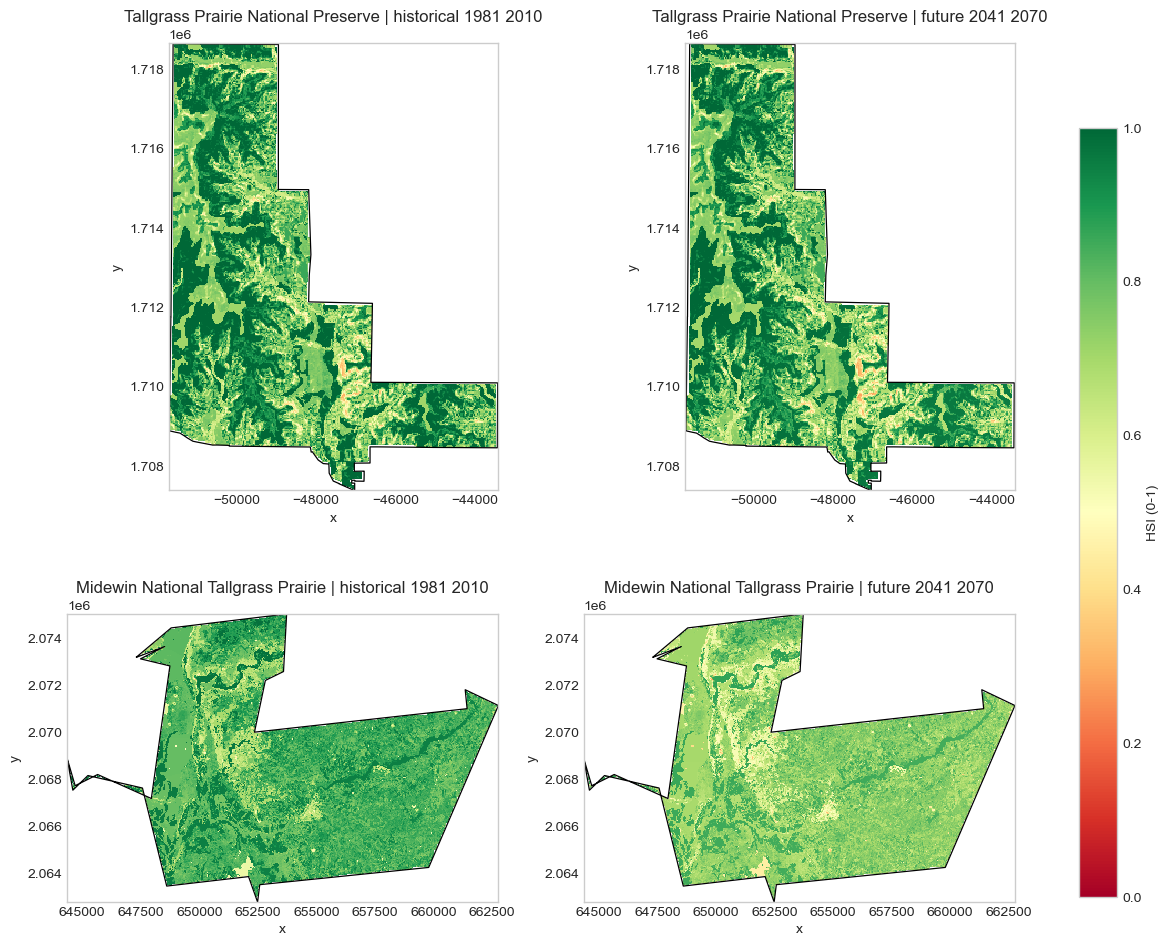

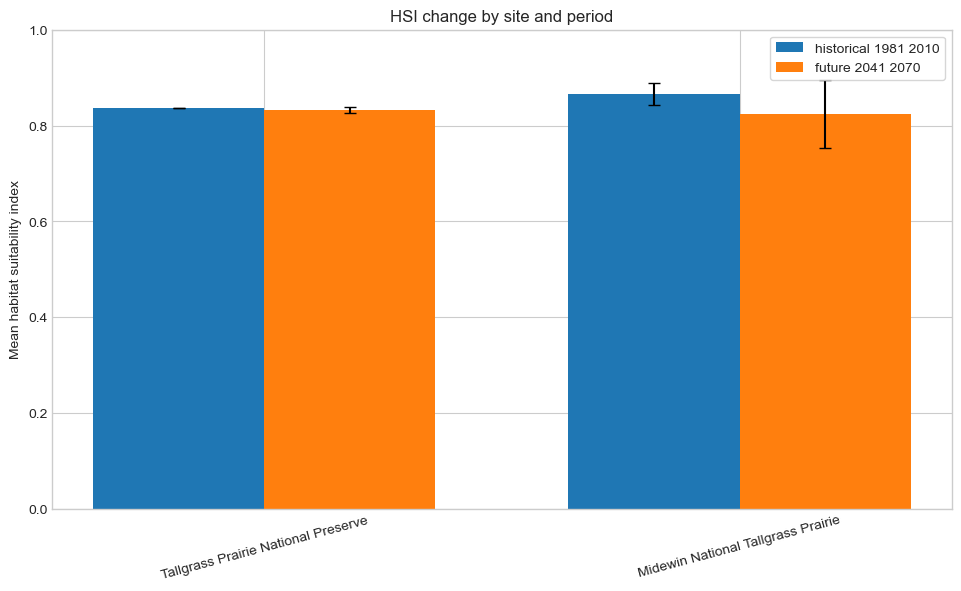

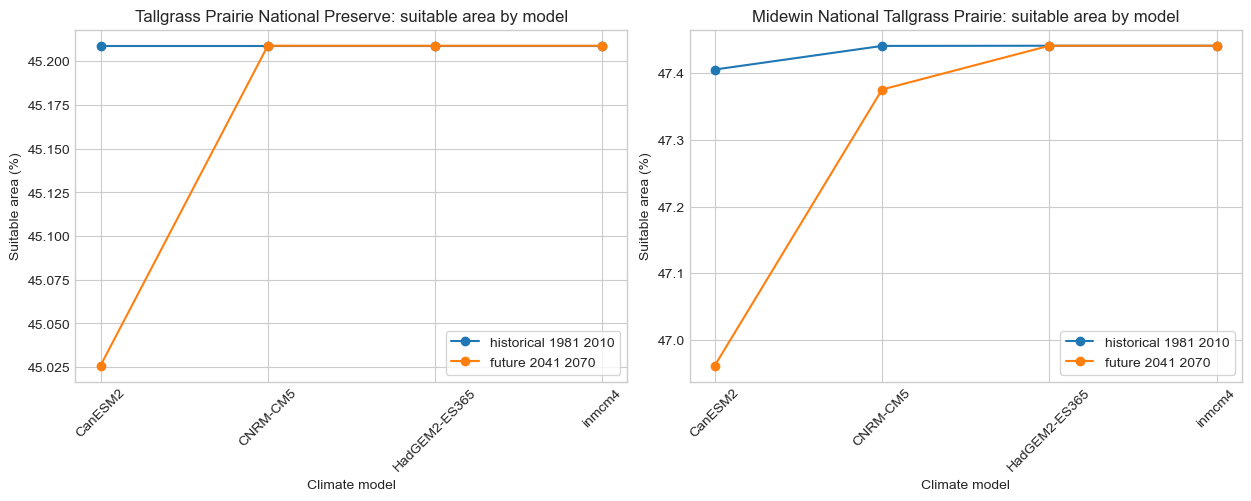

Saved figures:
 - c:\Users\kayle\Desktop\earth-analytics\spring-03-habitat-suitability-climate-change-kward-alt\figures\hsi_maps_CanESM2.png
 - c:\Users\kayle\Desktop\earth-analytics\spring-03-habitat-suitability-climate-change-kward-alt\figures\hsi_summary_bars.png
 - c:\Users\kayle\Desktop\earth-analytics\spring-03-habitat-suitability-climate-change-kward-alt\figures\hsi_model_uncertainty.png


,site_id,site_name,model,period,scenario,mean_hsi,median_hsi,suitable_area_pct,boundary_source
13,midewin_il,Midewin National Tallgrass Prairie,CNRM-CM5,future_2041_2070,rcp85,0.811836,0.814465,47.375374,USFS Forest Administrative Boundaries map serv...
12,midewin_il,Midewin National Tallgrass Prairie,CanESM2,future_2041_2070,rcp85,0.729039,0.732174,46.961803,USFS Forest Administrative Boundaries map serv...
14,midewin_il,Midewin National Tallgrass Prairie,HadGEM2-ES365,future_2041_2070,rcp85,0.877429,0.884521,47.440987,USFS Forest Administrative Boundaries map serv...
15,midewin_il,Midewin National Tallgrass Prairie,inmcm4,future_2041_2070,rcp85,0.877429,0.884521,47.440987,USFS Forest Administrative Boundaries map serv...
9,midewin_il,Midewin National Tallgrass Prairie,CNRM-CM5,historical_1981_2010,historical,0.875676,0.881866,47.440712,USFS Forest Administrative Boundaries map serv...
8,midewin_il,Midewin National Tallgrass Prairie,CanESM2,historical_1981_2010,historical,0.832186,0.835297,47.405319,USFS Forest Administrative Boundaries map serv...
10,midewin_il,Midewin National Tallgrass Prairie,HadGEM2-ES365,historical_1981_2010,historical,0.877429,0.884521,47.440987,USFS Forest Administrative Boundaries map serv...
11,midewin_il,Midewin National Tallgrass Prairie,inmcm4,historical_1981_2010,historical,0.877429,0.884521,47.440987,USFS Forest Administrative Boundaries map serv...
5,tallgrass_ks,Tallgrass Prairie National Preserve,CNRM-CM5,future_2041_2070,rcp85,0.835842,0.848745,45.208912,NPS Tallgrass Prairie National Preserve Tract ...
4,tallgrass_ks,Tallgrass Prairie National Preserve,CanESM2,future_2041_2070,rcp85,0.822770,0.834018,45.025940,NPS Tallgrass Prairie National Preserve Tract ...


In [31]:
if suitability_manifest_df.empty or suitability_summary_df.empty:
    raise RuntimeError("No suitability outputs available. Run the fuzzy-model cell first.")

period_order = [tp["period"] for tp in time_periods]
site_order = [rec["site_id"] for rec in site_records]
site_name_lookup = official_sites_gdf.set_index("site_id")["site_name"].to_dict()

# Plot 1: Suitability maps for one representative model across periods
map_model = climate_models[0]
fig, axes = plt.subplots(
    len(site_order),
    len(period_order),
    figsize=(5.8 * len(period_order), 4.9 * len(site_order)),
    constrained_layout=True,
)
if len(site_order) == 1:
    axes = np.array([axes])
if len(period_order) == 1:
    axes = axes.reshape(len(site_order), 1)

image_for_cbar = None
for i, site_id in enumerate(site_order):
    for j, period in enumerate(period_order):
        ax = axes[i, j]
        row = suitability_manifest_df[
            (suitability_manifest_df["site_id"] == site_id)
            & (suitability_manifest_df["model"] == map_model)
            & (suitability_manifest_df["period"] == period)
        ]

        if row.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_axis_off()
            continue

        hsi_da = rxr.open_rasterio(row.iloc[0]["hsi_path"], masked=True).squeeze(drop=True)
        site_boundary = official_sites_gdf.loc[official_sites_gdf["site_id"] == site_id].copy()
        boundary_raster = site_boundary.to_crs(hsi_da.rio.crs)

        hsi_plot_da = hsi_da.rio.clip(boundary_raster.geometry, boundary_raster.crs, drop=True)
        image_for_cbar = hsi_plot_da.plot(
            ax=ax,
            cmap="RdYlGn",
            vmin=0,
            vmax=1,
            add_colorbar=False,
        )
        boundary_raster.boundary.plot(ax=ax, color="black", linewidth=0.9)
        ax.set_title(f"{site_name_lookup.get(site_id, site_id)} | {period.replace('_', ' ')}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")

if image_for_cbar is not None:
    fig.colorbar(image_for_cbar, ax=axes.ravel().tolist(), shrink=0.82, label="HSI (0-1)")

map_fig_path = FIG_DIR / f"hsi_maps_{map_model}.png"
fig.savefig(map_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# Plot 2: Mean suitability by site and period (error bars = model spread)
summary_stats = (
    suitability_summary_df.groupby(["site_id", "period"], as_index=False)
    .agg(mean_hsi=("mean_hsi", "mean"), std_hsi=("mean_hsi", "std"))
)

fig, ax = plt.subplots(figsize=(9.5, 5.8), constrained_layout=True)
x = np.arange(len(site_order))
width = 0.36

for k, period in enumerate(period_order):
    vals, errs = [], []
    for site_id in site_order:
        row = summary_stats[(summary_stats["site_id"] == site_id) & (summary_stats["period"] == period)]
        if row.empty:
            vals.append(np.nan)
            errs.append(0.0)
        else:
            vals.append(float(row.iloc[0]["mean_hsi"]))
            errs.append(float(0.0 if np.isnan(row.iloc[0]["std_hsi"]) else row.iloc[0]["std_hsi"]))

    offset = (k - (len(period_order) - 1) / 2) * width
    ax.bar(x + offset, vals, width=width, yerr=errs, capsize=4, label=period.replace("_", " "))

ax.set_xticks(x)
ax.set_xticklabels([site_name_lookup.get(site_id, site_id) for site_id in site_order], rotation=15)
ax.set_ylim(0, 1)
ax.set_ylabel("Mean habitat suitability index")
ax.set_title("HSI change by site and period")
ax.legend(frameon=True)

summary_fig_path = FIG_DIR / "hsi_summary_bars.png"
fig.savefig(summary_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# Plot 3: Suitable area (%) by model
fig, axes = plt.subplots(1, len(site_order), figsize=(6.2 * len(site_order), 4.9), constrained_layout=True)
if len(site_order) == 1:
    axes = [axes]

for ax, site_id in zip(axes, site_order):
    site_df = suitability_summary_df[suitability_summary_df["site_id"] == site_id].copy()
    for period in period_order:
        period_df = site_df[site_df["period"] == period]
        ax.plot(
            period_df["model"],
            period_df["suitable_area_pct"],
            marker="o",
            linewidth=1.5,
            label=period.replace("_", " "),
        )
    ax.set_title(f"{site_name_lookup.get(site_id, site_id)}: suitable area by model")
    ax.set_ylabel("Suitable area (%)")
    ax.set_xlabel("Climate model")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(frameon=True)

uncertainty_fig_path = FIG_DIR / "hsi_model_uncertainty.png"
fig.savefig(uncertainty_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(f" - {map_fig_path}")
print(f" - {summary_fig_path}")
print(f" - {uncertainty_fig_path}")

suitability_summary_df.sort_values(["site_id", "period", "model"]).head(12)


In [32]:
# I want to see the change more clearly
# The Midewin site has more model heterogenity than the Tallgrass KS site
# Do a pivot of the future subtracted from the historical
df = suitability_summary_df.copy()
pivot = df.pivot_table(
    index=["site_id", "model"],
    columns="period",
    values="mean_hsi"
)
pivot["delta_hsi"] = pivot["future_2041_2070"] - pivot["historical_1981_2010"]
pivot.reset_index()

period,site_id,model,future_2041_2070,historical_1981_2010,delta_hsi
0,midewin_il,CNRM-CM5,0.811836,0.875676,-0.063840
1,midewin_il,CanESM2,0.729039,0.832186,-0.103147
2,midewin_il,HadGEM2-ES365,0.877429,0.877429,0.000000
3,midewin_il,inmcm4,0.877429,0.877429,0.000000
4,tallgrass_ks,CNRM-CM5,0.835842,0.835842,0.000000
5,tallgrass_ks,CanESM2,0.822770,0.835842,-0.013071
6,tallgrass_ks,HadGEM2-ES365,0.835842,0.835842,0.000000
7,tallgrass_ks,inmcm4,0.835842,0.835842,0.000000


### Key takeaway

Climate change produces *very* modest declines in habitat quality (HSI) while the overall extent of suitable habitat remains largely stable across both sites. Differences between sites persist, but are less pronounced than in earlier model runs (re:boundarygate). Tallgrass Prairie (KS) remains highly stable, while Midewin (IL) shows *slightly* greater sensitivity to future conditions.

### Larger analysis

Across both sites, the fuzzy model indicates that habitat suitability for *_Sorghastrum nutans_* remains consistently high under both historical (1981–2010) and future (2041–2070) climate conditions (precipitation). Mean habitat suitability values are slightly higher under historical conditions and decline modestly in future projections, particularly at the Midewin National Tallgrass Prairie site.

At Midewin, mean HSI decreases from approximately 0.87 to 0.82, indicating a measurable reduction in overall habitat quality. However, the percentage of area classified as suitable remains nearly unchanged (~47%), suggesting that while conditions become somewhat less optimal, most of the landscape remains above the suitability threshold. This pattern indicates a within-class decline in suitability, rather than a large-scale loss of suitable habitat.

In contrast, the Tallgrass Prairie site shows minimal change between historical and future conditions. Mean HSI values remain nearly constant (~0.84), and suitable area also remains stable (~45%). This suggests that Tallgrass Prairie is relatively robust to projected mid-century climate changes, at least under the variables included in this model.

Compared to earlier iterations of this analysis (re:boundarygate), differences across climate models are less pronounced. This reflects improvements in spatial processing, including the use of official site boundaries and more consistent raster alignment. As a result, I believe the updated outputs provide a more stable and realistic estimate of habitat suitability.

#### Quanitfying change over time due to model differences

Although earlier runs suggested strong model disagreement—particularly at the Midewin site—the updated results indicate more consistent outcomes across models. Rather than large divergences, the primary pattern is a modest decline in mean suitability at Midewin and near-complete stability at Tallgrass.

This suggests that projected climate impacts on *_Sorghastrum nutans_* habitat are relatively subtle at the spatial scale of this analysis. The results emphasize that changes in habitat quality may occur without large changes in total suitable area.

For example in the pivot table, examining model-specific changes in habitat suitability reveals that the CanESM2 model (warm + wet projection) produces the largest declines in HSI at both sites. *This is expected* since my climate variable was precipitation. In contrast, the HadGEM2 model (often characterized as warmer and drier) shows little to no change in suitability.

I first thought that drier conditions should to reduce habitat suitability more strongly. However, I have to think how the model thinks, so this pattern reflects the structure of the fuzzy model, which is primarily driven by precipitation rather than temperature. In this framework, increases in precipitation beyond the optimal range can reduce suitability just as much as decreases below it. As a result, the “warm + wet” scenario produces larger declines because it pushes conditions outside the modeled optimal precipitation window, whereas the “warm + dry” scenario may still fall within acceptable bounds even if we know the US will experience warming. 

#### Limitations
I used a compact fuzzy rule set (soil pH, slope, precipitation) and did not include disturbance regime (e.g., fire/grazing), land use, or dispersal constraints, so the maps represent only potential climatic suitability.

Additionally, while official administrative boundaries were used to improve spatial accuracy, these boundaries do not perfectly correspond to ecological prairie extent. Therefore, the results and plots I have should be interpreted as approximate representations of site-level suitability rather than precise delineations of habitat.

#### More grass digging--Why is the grass not *greener* on the other *site*

The biggest limitation, based on the literature, is actually the inability of my fuzzy model to capture fire ecology. As mentioned in the introduction at the beginning of this notebook, fire suppression may negative effect indiangrass because it allows intrusion by woody species. This is important because as Walker (1991) states, "The maintenance of the tallgrass prairie before European settlement was largely due to the occurrence of fire.  In the absence of fire, invasion by woody species is common [12].  Without periodic fires Indiangrass declines in terms of reproductive effort and relative cover [32]. Indiangrass survives fire by sprouting from on-site surviving rhizomes." (*FIRE ECOLOGY OR ADAPTATIONS*). 

Because fire regime is not included in my model, these results reflect climatic suitability only and may underestimate the importance of disturbance processes in maintaining high-quality habitat. This would be important to model because Walker (1991) makes it clear that fire is good for this species and can rebound quickly depending on the season. Noteably annual burns are important. I am including the excerpt from the section *PLANT RESPONSE TO FIRE*

    Indiangrass density and apparent vigor [17,22], number of flowering
    culms [9,38,45], and percent canopy and basal cover [5,57] increase with
    late spring burning conducted prior to green-up.  Burning during other
    seasons may increase flowering stems [38] or decrease percent
    composition of Indiangrass [72].  The greatest increase in canopy cover,
    density, production, and flowering occurs following annual burns
    [2,25,44,45].  Seeds are generally absent in burned soils, and most
    reproduction following fire is vegetative [2].  Fire intensity affects
    short-term rhizome reproduction.  Late summer fires (September 5th) were
    conducted with both high-intensity and low-intensity fuels.  Little or
    no damage occurred on the low-intensity fuel area, but tiller densities
    were reduced on the high-intensity fuel area.  However, tiller density
    returned to normal by the following August. (Walker, 1991).

It would be interesting to model the affects of changing fire regimes, especially as humans try to tamp down on fires as much as possible. **My hypothesis is that: Kansas is less densely populated than Illinois, which may allow for more frequent use of prescribed fire and fewer constraints on fire management. In contrast, more developed landscapes in Illinois may limit the use of fire as a management tool, potentially influencing habitat conditions for fire-dependent species.** If we look at the site plots from early with the topo basemaps, the Illinois site is encircled by built environments, so I imagine the likelihood of prescribed burns is very low compared to Kansas. 

Reference: 
Walkup, Crystal J. 1991. Sorgastrum nutans. In: Fire Effects Information System, [Online]. 
U.S. Department of Agriculture, Forest Service, Rocky Mountain Research Station, 
Fire Sciences Laboratory (Producer). Available: 
https://www.fs.usda.gov/database/feis/plants/graminoid/sornut/all.html [2026, March 23].